# Notebook to analyse the results of the built models.

In [1]:
# @title
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
sys.path.append(WORK_DIR_ROOT)

from utils import *
from ResNet50_1_definitions import *
from VitClassifier_1_defnitions import *



DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/datasets_resized_stratified/"
DATASET_RESIZED_B_M = f"{WORK_DIR_ROOT}/mal_ben_datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"


CHECKPOINT_DIR = WORK_DIR_ROOT + 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Mounted at /content/drive


### Code for equalized odds - Fairness analysis metric

Aims to analyse the performance of models with regards to the different groups: sex, skin tone, age.

We aim to minimize the difference between performance for different groups. For example Equalized odd for sex: 0.0003 is extremely disbalanced compared to Equalized odd for gender: 1.006

Generalized fairness score aims to reach towards 1 for a perfect classification of samples with regards their protected group.



In [2]:
from utils import equalized_odds_by_group_multiclass, equalized_odds_gap, generalized_fairness_score, compute_fairness_std, compute_fairness

# 1.1 UNIMODAL: 11 categories

## VALIDATION set

## Load vaidation and test data


In [ ]:
# @title
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type","age_approx", "sex", "skin_tone_class"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

from utils import load_lesion_splits

_, val_lesions , _ = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Val: {len(val_lesions)}"
)


# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

Val: 524


In [ ]:
# @title
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from utils import Milk10kDataset_unimodal
from torch.utils.data import DataLoader
import os

validation_transform = transforms.Compose([
    transforms.ToTensor()])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

val_dataset   = Milk10kDataset_unimodal(df_val_clinical,
                                        DATASET_RESIZED + "/validation",
                                        transform=validation_transform)

NUM_WORKERS = os.cpu_count()

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader

Using device: cpu


#### Labels of the samples, regarding the sensitive groups

In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
65.0    75
70.0    66
50.0    61
75.0    56
60.0    53
55.0    50
85.0    42
80.0    37
45.0    37
40.0    15
35.0    12
30.0     9
15.0     5
25.0     4
5.0      1
Name: count, dtype: int64
<30       10
31-39     21
41-49     52
51-59    111
61-69    128
71-79    122
>80       79
Name: count, dtype: int64
1     11
2     50
3    319
4    107
5     37
Name: count, dtype: int64
0-1     11
2       50
3      319
4      107
5       37
Name: count, dtype: int64


In [ ]:
print(df_val_clinical["age_approx"].isna().sum())

1


## Test models

## (1) ResNet50 model

2 stage: first the head, second the whole model, learning rate chosen by Optuna: 1e-3 for head, 7e-5 for full

Methods located in `ResNet50_1_definitions.py`

2 stages located in checkpoints folder:  `RESNET_1_best_stage1.pt, RESNET_1_best_stage2.pt`

In [ ]:
# @title
from ResNet50_1_definitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load the model as saved in the checkpoints dir:
model = ResNet50Classifier(num_classes=11).to(device)

checkpoint_path = CHECKPOINT_DIR + "/RESNET_1_best_stage2.pt"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)


Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


<All keys matched successfully>

In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6545801758766174


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.718750  0.063203       21
1  41-49  0.370289  0.044141       52
2  51-59  0.397056  0.052907      111
3  61-69  0.347879  0.046558      128
4  71-79  0.330325  0.055532      122
5    <30  0.833333  0.027273       10
6    >80  0.430405  0.050062       79

Age EO Gap
0.11656207321420606

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.391598  0.048173      208
1    male  0.410477  0.046286      316

Gender EO Gap
0.010382768666477575

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.466667  0.063131       11
1     2  0.314693  0.064506       50
2     3  0.430288  0.045564      319
3     4  0.534184  0.048745      107
4     5  0.277551  0.064672       37

Skin EO Gap
0.0719217741909342

Generalized Fairness Score
0.9337111279761273


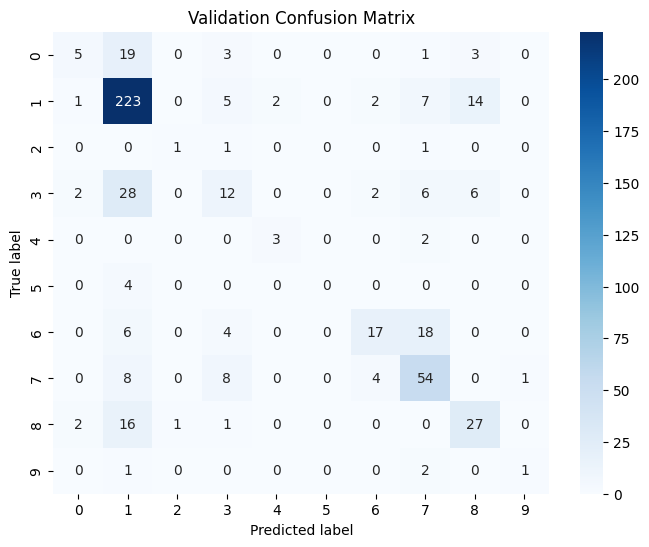

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.5000    0.1613    0.2439        31
           1     0.7311    0.8780    0.7979       254
           2     0.5000    0.3333    0.4000         3
           3     0.3529    0.2143    0.2667        56
           4     0.6000    0.6000    0.6000         5
           5     0.0000    0.0000    0.0000         4
           7     0.6800    0.3778    0.4857        45
           8     0.5934    0.7200    0.6506        75
           9     0.5400    0.5745    0.5567        47
          10     0.5000    0.2500    0.3333         4

    accuracy                         0.6546       524
   macro avg     0.4997    0.4109    0.4335       524
weighted avg     0.6259    0.6546    0.6250       524

Top-3 Accuracy: 0.9275


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.3569601770307957), np.float64(0.8588853296527825), np.float64(0.3459000165415434), np.float64(0.2961669745009537), np.float64(0.738158508158508), np.float64(0.29895990249341775), np.float64(0.5), np.float64(0.5545860586826374), np.float64(0.6797413324175705), np.float64(0.6418749858925951), np.float64(0.17630547780887645)]
Validation PR-AUC (weighted): 0.6842
Validation PR-AUC (macro): 0.4952


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


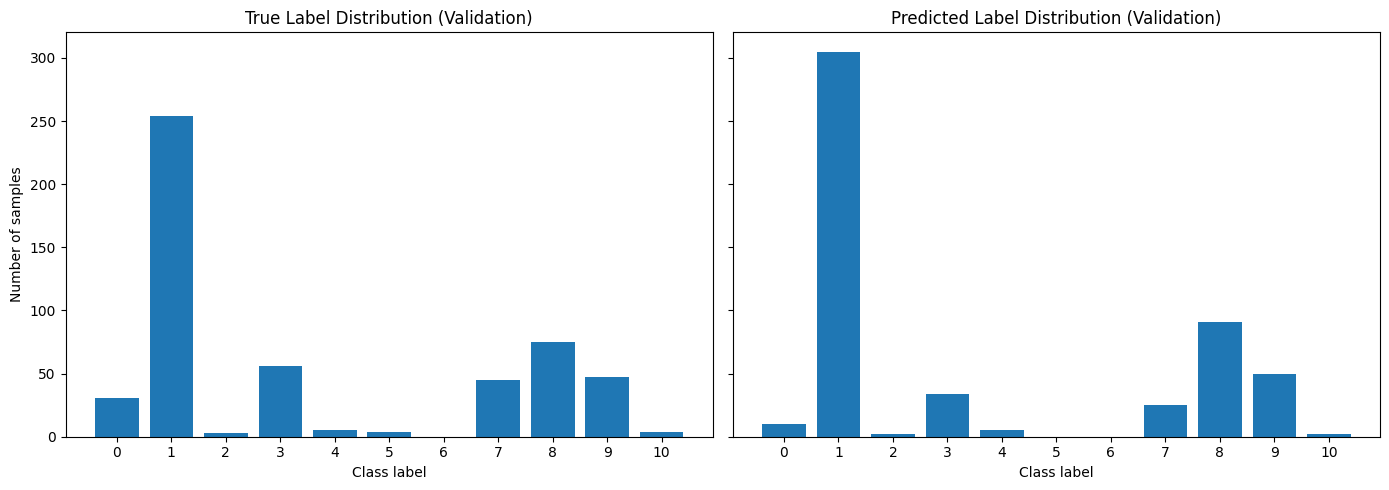

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

#### Summary on performance

The model achieves an overall validation accuracy of 65.5%, with a Top-3 accuracy of 92.8%, indicating that the correct class is frequently among the model’s highest-confidence predictions. This suggests that most misclassifications correspond to visually or semantically similar classes rather than random errors.

However, the macro-averaged F1-score (0.43) is significantly lower than the weighted F1-score (0.63), highlighting a strong performance disparity across classes. This discrepancy is largely explained by class imbalance in the validation set, where frequent classes (e.g., class 1) dominate the weighted metrics.

Performance on minority classes is notably weaker. Several low-support classes exhibit poor recall, and class 5 is not correctly predicted at all, indicating that the model struggles to learn discriminative features for rare categories. These results suggest that the model prioritizes dominant classes during training, leading to reduced sensitivity for under-represented labels.

Overall, while the model demonstrates strong ranking capability (high Top-3 accuracy), further improvements are needed to address class imbalance and improve recall for rare classes.

## (2) ResNet18 model


In [ ]:
# @title
from ResNet18_1_definitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint_path = f"{CHECKPOINT_DIR}/Resnet_2_stage2_best.pt"

model = ResNet18Classifier(num_classes=11).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6469465494155884


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.35644336015764144), np.float64(0.8263043364394805), np.float64(0.34971301787158565), np.float64(0.2514393158220308), np.float64(0.7168713450292397), np.float64(0.30106293917435223), np.float64(0.5), np.float64(0.519340196885135), np.float64(0.670661269190853), np.float64(0.5668532713235422), np.float64(0.36612272985441463)]
Validation PR-AUC (weighted): 0.6539
Validation PR-AUC (macro): 0.4932


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.718750  0.064141       21
1  41-49  0.168376  0.071894       52
2  51-59  0.419306  0.048574      111
3  61-69  0.289885  0.050518      128
4  71-79  0.361615  0.052977      122
5    <30  0.388889  0.109091       10
6    >80  0.294203  0.058904       79

Age EO Gap
0.10667229271674136

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.344697  0.047338      208
1    male  0.272308  0.052127      316

Gender EO Gap
0.03858921710740408

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.371985  0.060092       50
2     3  0.309135  0.052107      319
3     4  0.319546  0.047774      107
4     5  0.221769  0.065007       37

Skin EO Gap
0.10141696448454832

Generalized Fairness Score
0.9177738418971021


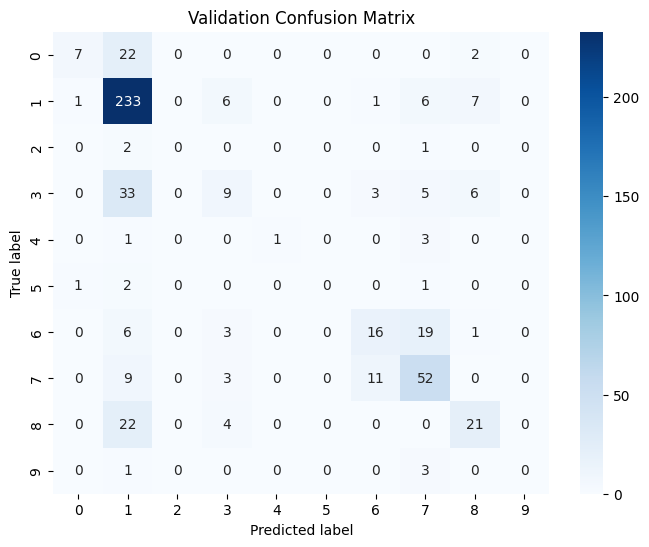

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.7778    0.2258    0.3500        31
           1     0.7039    0.9173    0.7966       254
           2     0.0000    0.0000    0.0000         3
           3     0.3600    0.1607    0.2222        56
           4     1.0000    0.2000    0.3333         5
           5     0.0000    0.0000    0.0000         4
           7     0.5161    0.3556    0.4211        45
           8     0.5778    0.6933    0.6303        75
           9     0.5676    0.4468    0.5000        47
          10     0.0000    0.0000    0.0000         4

    accuracy                         0.6469       524
   macro avg     0.4503    0.3000    0.3253       524
weighted avg     0.6132    0.6469    0.6050       524

Top-3 Accuracy: 0.9256


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


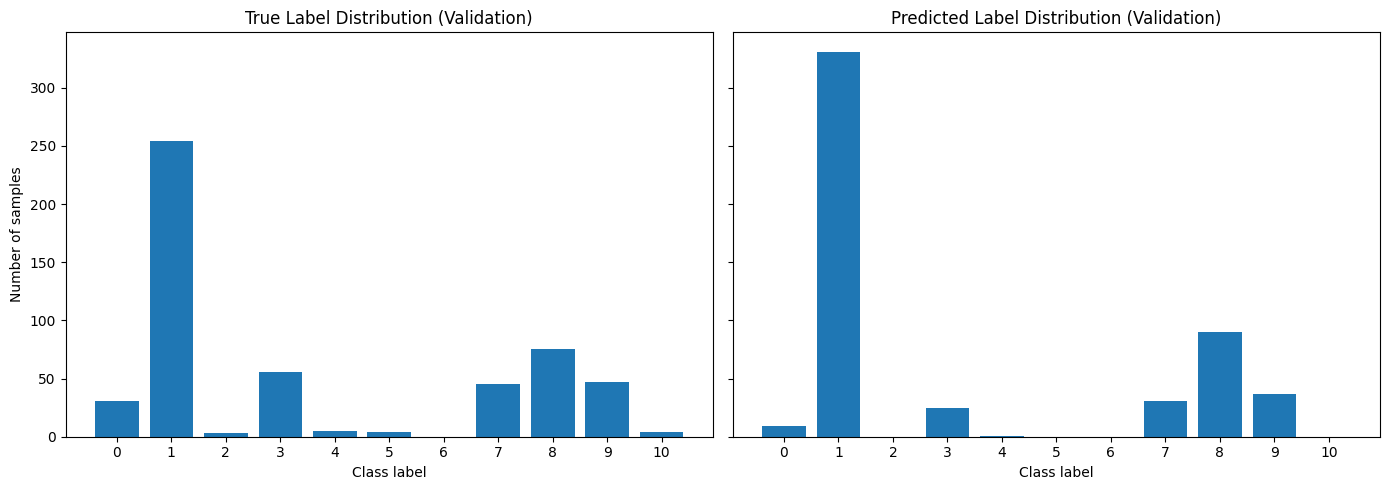

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## (3) ViT 1st model

In [ ]:
# @title
from VitClassifier_1_defnitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load the model as saved in the checkpoints dir:
model = ViTClassifier(num_classes=11).to(device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_1_best_stage2.pt"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

Using device: cpu
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 103MB/s] 


<All keys matched successfully>

In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6755725145339966


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.703125  0.068470       21
1  41-49  0.449573  0.052859       52
2  51-59  0.392869  0.049023      111
3  61-69  0.340649  0.038963      128
4  71-79  0.343000  0.052195      122
5    <30  0.888889  0.018182       10
6    >80  0.519238  0.047651       79

Age EO Gap
0.12735894044496776

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.454401  0.043633      208
1    male  0.353377  0.044798      316

Gender EO Gap
0.05109475614269658

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.600000  0.050505       11
1     2  0.314693  0.062647       50
2     3  0.449530  0.042741      319
3     4  0.421803  0.047178      107
4     5  0.269388  0.062089       37

Skin EO Gap
0.08507846379139189

Generalized Fairness Score
0.9121559465403145


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.41035201418806305), np.float64(0.8702908144709706), np.float64(0.3569548912461159), np.float64(0.25908065639991573), np.float64(0.45534181305955346), np.float64(0.10698396782955606), np.float64(0.5), np.float64(0.5321758293359995), np.float64(0.6830153088227865), np.float64(0.6213556463807215), np.float64(0.5231273889757786)]
Validation PR-AUC (weighted): 0.6842
Validation PR-AUC (macro): 0.4835


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


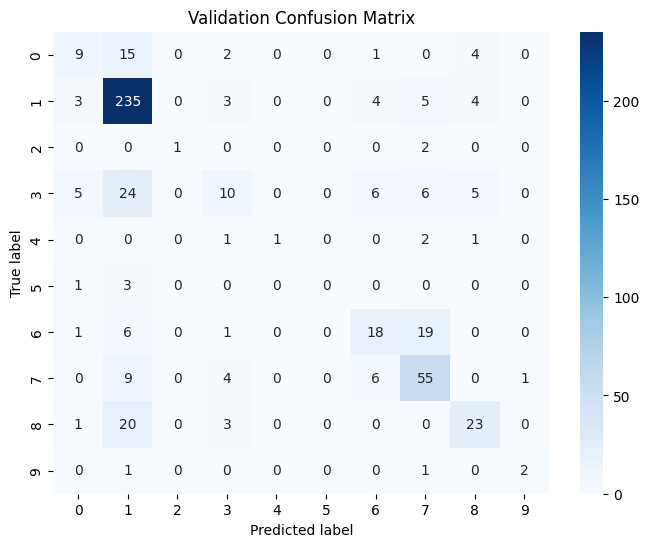

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.4500    0.2903    0.3529        31
           1     0.7508    0.9252    0.8289       254
           2     1.0000    0.3333    0.5000         3
           3     0.4167    0.1786    0.2500        56
           4     1.0000    0.2000    0.3333         5
           5     0.0000    0.0000    0.0000         4
           7     0.5143    0.4000    0.4500        45
           8     0.6111    0.7333    0.6667        75
           9     0.6216    0.4894    0.5476        47
          10     0.6667    0.5000    0.5714         4

    accuracy                         0.6756       524
   macro avg     0.6031    0.4050    0.4501       524
weighted avg     0.6428    0.6756    0.6430       524

Top-3 Accuracy: 0.9122


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


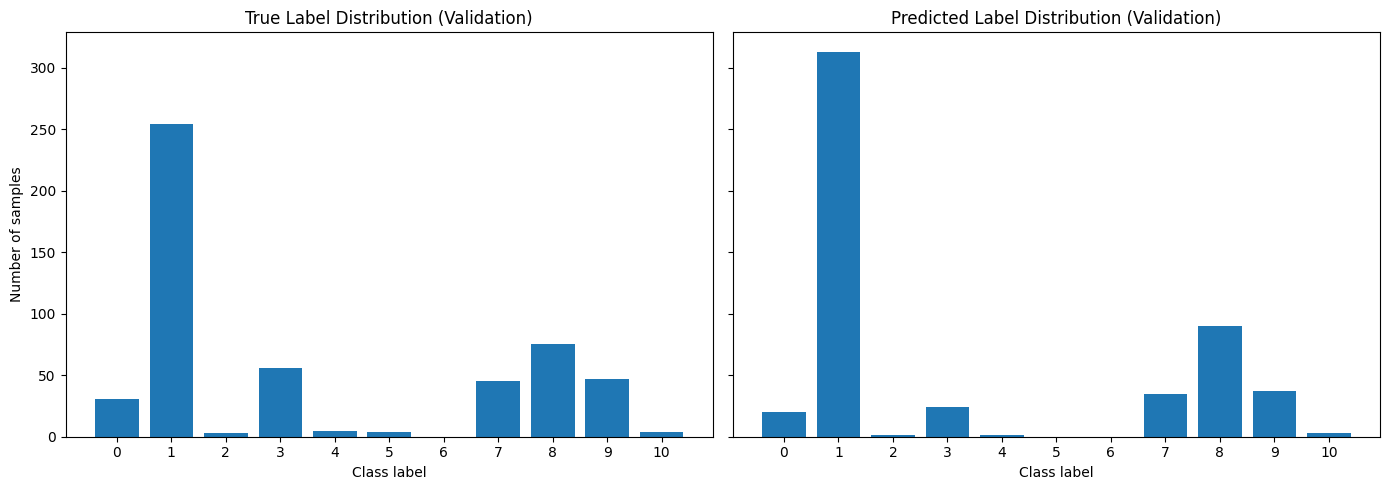

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## (4) ViT 2nd model


In [ ]:
# @title
from VitClassifier_2_definitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_2_stage2_best.pt"

model = ViTClassifierCLSPool(num_classes=11).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6583969593048096


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.718750  0.063420       21
1  41-49  0.372934  0.056471       52
2  51-59  0.358339  0.052210      111
3  61-69  0.320476  0.051632      128
4  71-79  0.315332  0.055376      122
5    <30  0.944444  0.009091       10
6    >80  0.408536  0.056749       79

Age EO Gap
0.1386459223258254

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.409790  0.050713      208
1    male  0.381366  0.048727      316

Gender EO Gap
0.01520484932283124

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.600000  0.050505       11
1     2  0.412555  0.064808       50
2     3  0.412957  0.050694      319
3     4  0.477651  0.048414      107
4     5  0.221769  0.070856       37

Skin EO Gap
0.08807447514865914

Generalized Fairness Score
0.9193582510675613


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.35372334215852885), np.float64(0.8566397573302151), np.float64(0.473005698005698), np.float64(0.23298563029907365), np.float64(0.6588888888888889), np.float64(0.11677833830293785), np.float64(0.5), np.float64(0.5511941483314794), np.float64(0.6519254033805563), np.float64(0.6282589824056088), np.float64(0.5237388470480695)]
Validation PR-AUC (weighted): 0.6719
Validation PR-AUC (macro): 0.5043


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


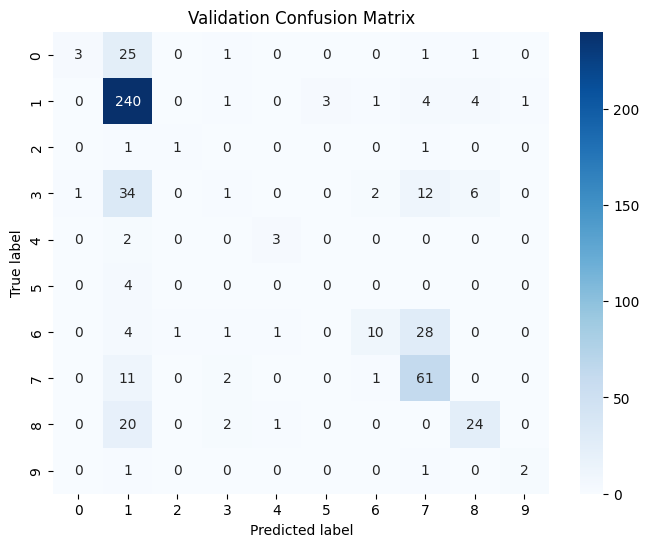

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.7500    0.0968    0.1714        31
           1     0.7018    0.9449    0.8054       254
           2     0.5000    0.3333    0.4000         3
           3     0.1250    0.0179    0.0312        56
           4     0.6000    0.6000    0.6000         5
           5     0.0000    0.0000    0.0000         4
           7     0.7143    0.2222    0.3390        45
           8     0.5648    0.8133    0.6667        75
           9     0.6857    0.5106    0.5854        47
          10     0.6667    0.5000    0.5714         4

    accuracy                         0.6584       524
   macro avg     0.5308    0.4039    0.4170       524
weighted avg     0.6153    0.6584    0.5933       524

Top-3 Accuracy: 0.9256


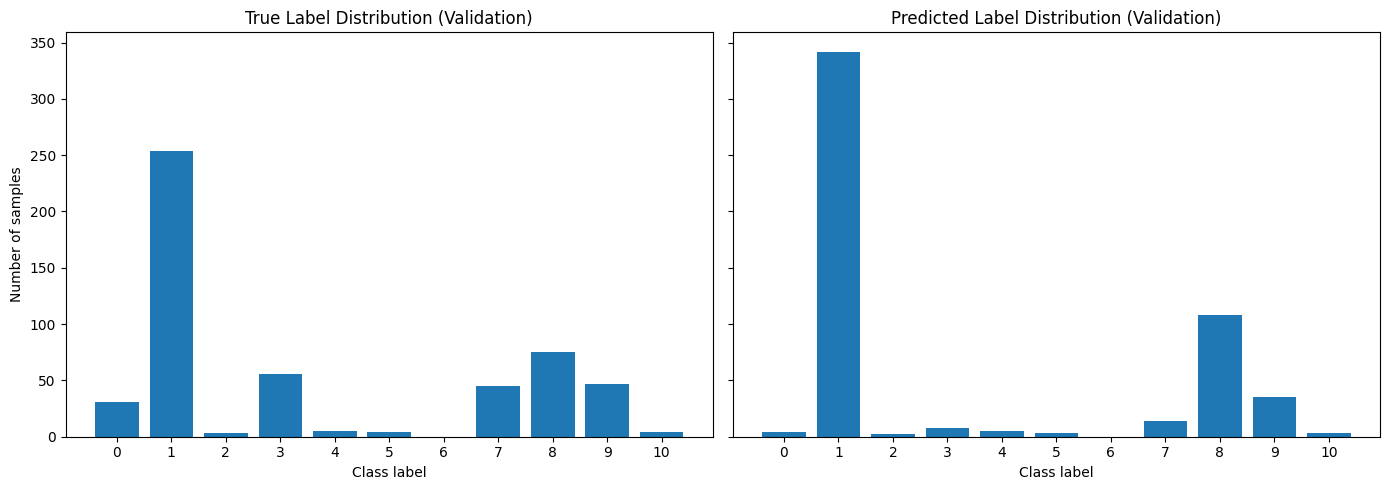

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## (5) ViT 3rd model

In [ ]:
# @title
from VitClassifier_3_definitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_3_stage2_best.pt"

model = ViTClassifierDeepHead(num_classes=11).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6488549709320068


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.3338862311785405), np.float64(0.8534555458127423), np.float64(0.4022270955165692), np.float64(0.2621393233186841), np.float64(0.41620280995280995), np.float64(0.05021461056908818), np.float64(0.5), np.float64(0.513741507937773), np.float64(0.6736760560224607), np.float64(0.6194020327034393), np.float64(0.1591141394678709)]
Validation PR-AUC (weighted): 0.6654
Validation PR-AUC (macro): 0.4349


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.718750  0.063925       21
1  41-49  0.200285  0.063599       52
2  51-59  0.357155  0.055924      111
3  61-69  0.276537  0.051123      128
4  71-79  0.373328  0.050334      122
5    <30  0.444444  0.100000       10
6    >80  0.480474  0.052424       79

Age EO Gap
0.10649217579917665

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.399397  0.047042      208
1    male  0.266912  0.051143      316

Gender EO Gap
0.06829289727122842

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.600000  0.050505       11
1     2  0.359101  0.059135       50
2     3  0.370618  0.050814      319
3     4  0.280286  0.052280      107
4     5  0.221769  0.067771       37

Skin EO Gap
0.08896477109477466

Generalized Fairness Score
0.9120833852782734


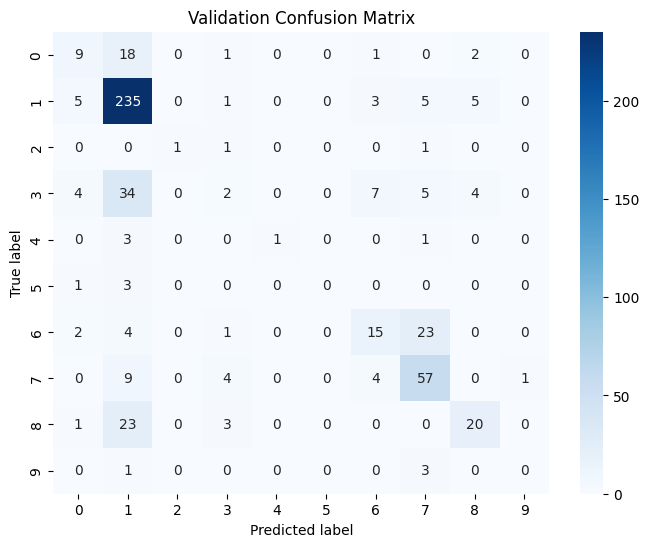

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.4091    0.2903    0.3396        31
           1     0.7121    0.9252    0.8048       254
           2     1.0000    0.3333    0.5000         3
           3     0.1538    0.0357    0.0580        56
           4     1.0000    0.2000    0.3333         5
           5     0.0000    0.0000    0.0000         4
           7     0.5000    0.3333    0.4000        45
           8     0.6000    0.7600    0.6706        75
           9     0.6452    0.4255    0.5128        47
          10     0.0000    0.0000    0.0000         4

    accuracy                         0.6489       524
   macro avg     0.5020    0.3303    0.3619       524
weighted avg     0.5878    0.6489    0.5988       524

Top-3 Accuracy: 0.9122


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


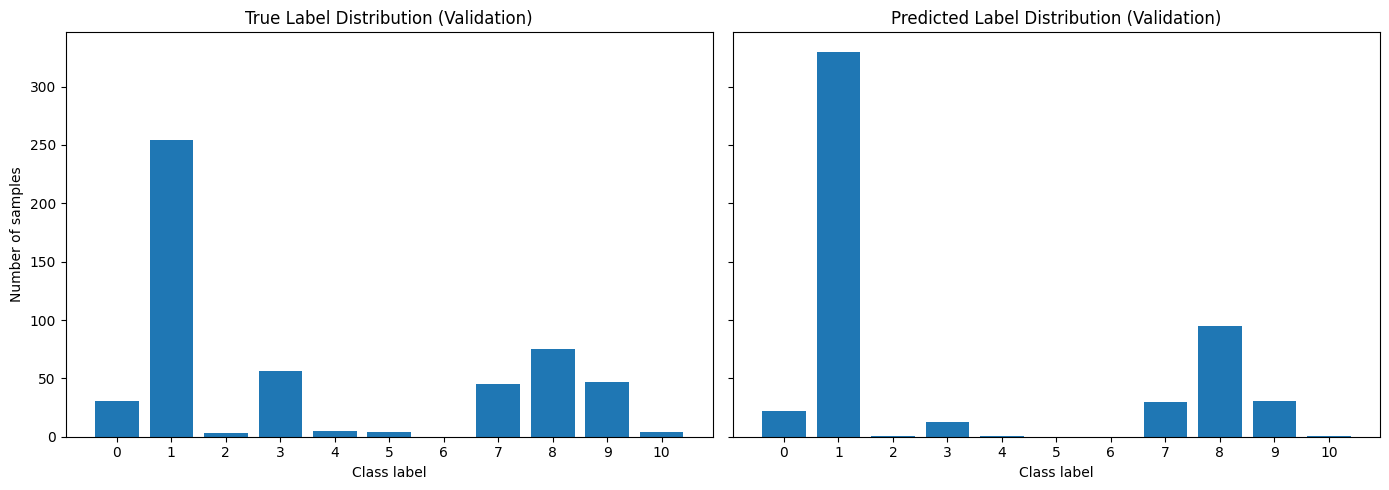

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

# 1.2 UNIMODAL: 2 categories

Benign/Malignant

## VALIDATION set

In [ ]:
from utils import LABEL_COLUMNS, BENIGNANT_NAMES, MALIGNANT_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

def decode_label_id(row):
    for col in LABEL_COLUMNS:
        if row[col] == 1:
          # check if it is bening or malign:
          if col in BENIGNANT_NAMES:
            return 0
          if col in MALIGNANT_NAMES:
            return 1
    return "UNKNOWN"

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

from utils import load_lesion_splits

_, val_lesions , _ = load_lesion_splits(
    WORK_DIR_ROOT + "/b_m_milk10k_lesion_splits.json"
)

print(
    f"Val: {len(val_lesions)}"
)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

Val: 524


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from utils import Milk10kDataset_unimodal
from torch.utils.data import DataLoader
import os

validation_transform = transforms.Compose([
    transforms.ToTensor()])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

val_dataset   = Milk10kDataset_unimodal(df_val_clinical,
                                        DATASET_RESIZED_B_M + "/validation",
                                        transform=validation_transform)

NUM_WORKERS = os.cpu_count()

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False, # important for the fairness analysis
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader

Using device: cpu


In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
70.0    77
65.0    75
75.0    70
60.0    56
55.0    54
50.0    44
80.0    34
85.0    30
45.0    27
40.0    23
30.0    13
35.0     9
20.0     3
25.0     3
15.0     2
5.0      1
10.0     1
Name: count, dtype: int64
<30       10
31-39     22
41-49     50
51-59     98
61-69    131
71-79    147
>80       64
Name: count, dtype: int64
0      1
1     10
2     50
3    317
4    107
5     39
Name: count, dtype: int64
0-1     11
2       50
3      317
4      107
5       39
Name: count, dtype: int64


## (1) RestNet50 backbone model

In [ ]:
# @title
from ResNet50_1_definitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
checkpoint_path = CHECKPOINT_DIR + "/RESNET_1_best_stage2_2_cat.pt"

# load the model as saved in the checkpoints dir:
model = ResNet50Classifier(num_classes=2).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]


Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.8015267252922058


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)


valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group(y_true_age, y_pred_age, age_groups)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group(y_true_n, y_pred_n, gender)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group(y_true_n, y_pred_n, skin)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.166667  0.187500       22
1  41-49  0.714286  0.310345       50
2  51-59  0.848485  0.468750       98
3  61-69  0.943396  0.640000      131
4  71-79  0.933333  0.444444      147
5    <30  0.000000  0.222222       10
6    >80  0.907407  0.600000       64

Age EO Gap
0.32514783017474563

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.855172  0.378378      219
1    male  0.912664  0.460526      305

Gender EO Gap
0.06981963953825354

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  1.000000  0.333333       11
1     2  0.636364  0.214286       50
2     3  0.917355  0.533333      317
3     4  0.883117  0.366667      107
4     5  0.857143  0.363636       39

Skin EO Gap
0.14589138134592683

Generalized Fairness Score
0.8197137163136913


In [ ]:
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

logits = logits.cpu()
y_true = y_true.cpu()

probs = torch.softmax(logits, dim=1)
pos_probs = probs[:, 1].numpy()
y_true_np = y_true.numpy()

# Accuracy
y_pred = probs.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()

# ROC-AUC
roc_auc = roc_auc_score(y_true_np, pos_probs)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, pos_probs)
pr_auc = auc(recall, precision)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation Accuracy: 0.8015
Validation ROC-AUC: 0.8336
Validation PR-AUC: 0.9106


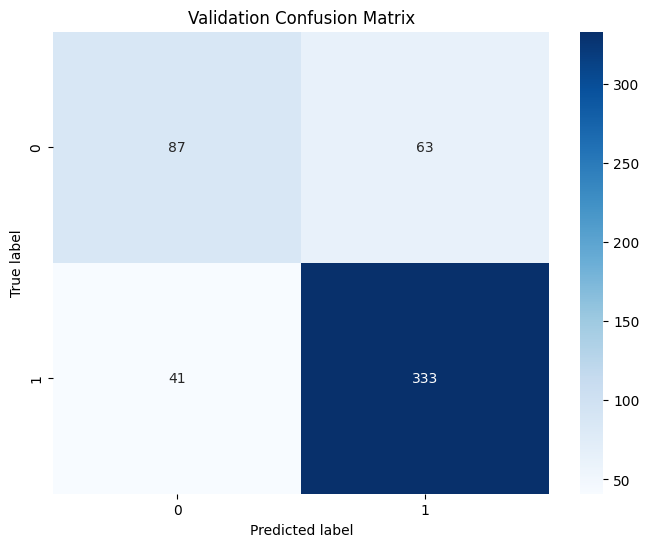

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.6797    0.5800    0.6259       150
           1     0.8409    0.8904    0.8649       374

    accuracy                         0.8015       524
   macro avg     0.7603    0.7352    0.7454       524
weighted avg     0.7948    0.8015    0.7965       524



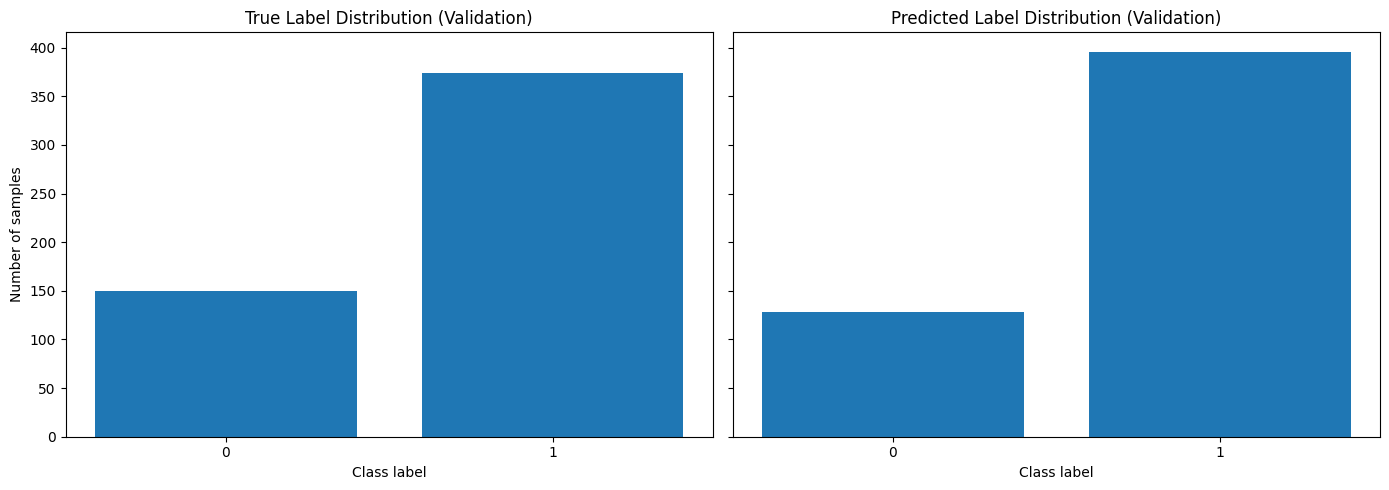

In [ ]:
# @title
num_classes = 2
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## (2) ResNet18 backbone classifier

In [ ]:
# @title
from ResNet18_1_definitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
checkpoint_path = CHECKPOINT_DIR + "/Resnet_2_stage2_best_2_cat.pt"

# load the model as saved in the checkpoints dir:
model = ResNet18Classifier(num_classes=2).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]


Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.8091602921485901


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group(y_true_age, y_pred_age, age_groups)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group(y_true_n, y_pred_n, gender)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group(y_true_n, y_pred_n, skin)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.333333  0.062500       22
1  41-49  0.761905  0.172414       50
2  51-59  0.833333  0.343750       98
3  61-69  0.896226  0.640000      131
4  71-79  0.916667  0.518519      147
5    <30  0.000000  0.222222       10
6    >80  0.888889  0.300000       64

Age EO Gap
0.3118575009101932

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.806897  0.283784      219
1    male  0.912664  0.407895      305

Gender EO Gap
0.11493907839634945

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.800000  0.333333       11
1     2  0.636364  0.178571       50
2     3  0.900826  0.386667      317
3     4  0.896104  0.366667      107
4     5  0.750000  0.454545       39

Skin EO Gap
0.12803109012199917

Generalized Fairness Score
0.8150574435238194


In [ ]:
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

logits = logits.cpu()
y_true = y_true.cpu()

probs = torch.softmax(logits, dim=1)
pos_probs = probs[:, 1].numpy()
y_true_np = y_true.numpy()

# Accuracy
y_pred = probs.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()

# ROC-AUC
roc_auc = roc_auc_score(y_true_np, pos_probs)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, pos_probs)
pr_auc = auc(recall, precision)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation Accuracy: 0.8092
Validation ROC-AUC: 0.8470
Validation PR-AUC: 0.9241


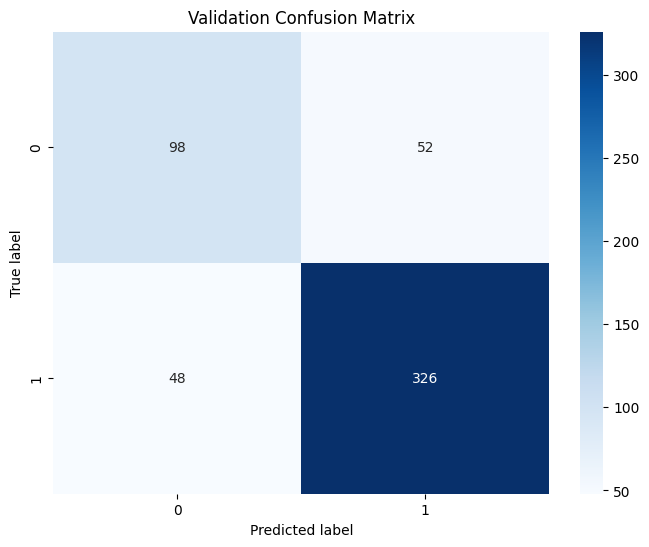

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.6712    0.6533    0.6622       150
           1     0.8624    0.8717    0.8670       374

    accuracy                         0.8092       524
   macro avg     0.7668    0.7625    0.7646       524
weighted avg     0.8077    0.8092    0.8084       524



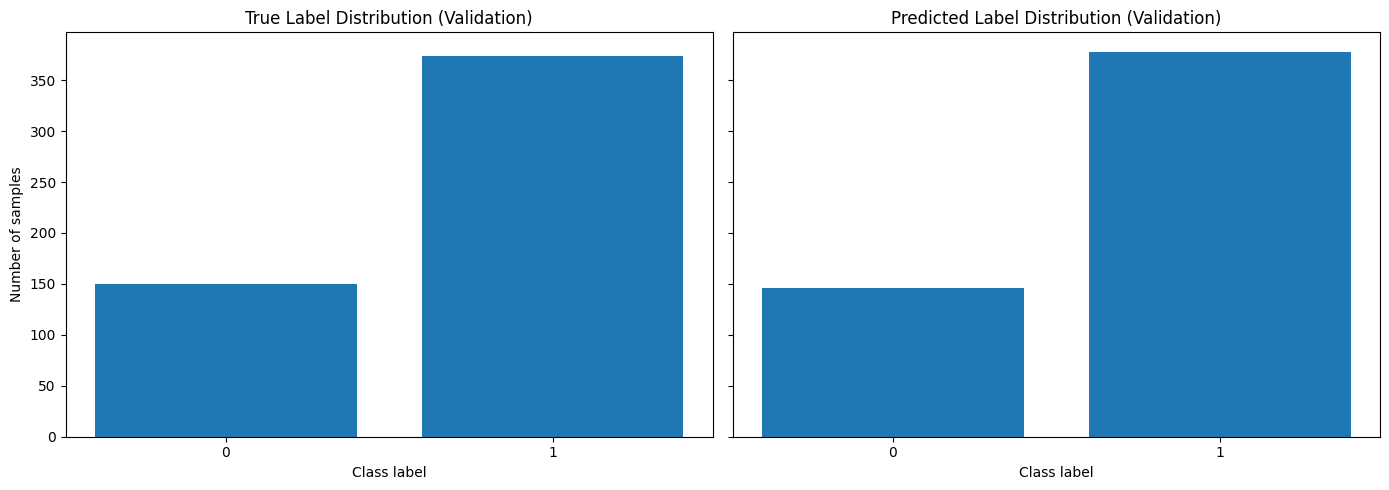

In [ ]:
# @title
num_classes = 2
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## (2) 1st Vit classifier

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_1_best_stage2_2_cat.pt"
model = ViTClassifier(num_classes=2).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.8034350872039795


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)


valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group(y_true_age, y_pred_age, age_groups)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group(y_true_n, y_pred_n, gender)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group(y_true_n, y_pred_n, skin)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.333333  0.125000       22
1  41-49  0.761905  0.206897       50
2  51-59  0.818182  0.312500       98
3  61-69  0.896226  0.680000      131
4  71-79  0.941667  0.518519      147
5    <30  0.000000  0.333333       10
6    >80  0.907407  0.600000       64

Age EO Gap
0.32212834363847476

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.841379  0.351351      219
1    male  0.903930  0.421053      305

Gender EO Gap
0.06612605044356759

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.800000  0.500000       11
1     2  0.681818  0.178571       50
2     3  0.909091  0.466667      317
3     4  0.844156  0.333333      107
4     5  0.892857  0.454545       39

Skin EO Gap
0.1323593073593074

Generalized Fairness Score
0.8264620995195501


In [ ]:
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

logits = logits.cpu()
y_true = y_true.cpu()

probs = torch.softmax(logits, dim=1)
pos_probs = probs[:, 1].numpy()
y_true_np = y_true.numpy()

# Accuracy
y_pred = probs.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()

# ROC-AUC
roc_auc = roc_auc_score(y_true_np, pos_probs)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, pos_probs)
pr_auc = auc(recall, precision)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation Accuracy: 0.8034
Validation ROC-AUC: 0.8341
Validation PR-AUC: 0.9151


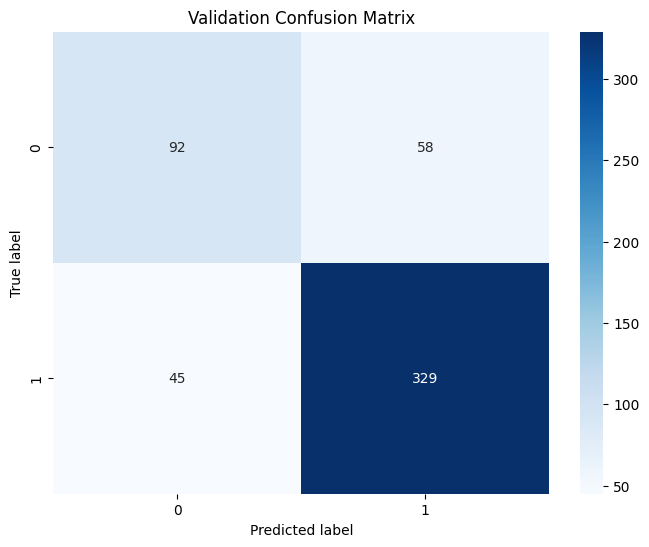

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.6715    0.6133    0.6411       150
           1     0.8501    0.8797    0.8647       374

    accuracy                         0.8034       524
   macro avg     0.7608    0.7465    0.7529       524
weighted avg     0.7990    0.8034    0.8007       524



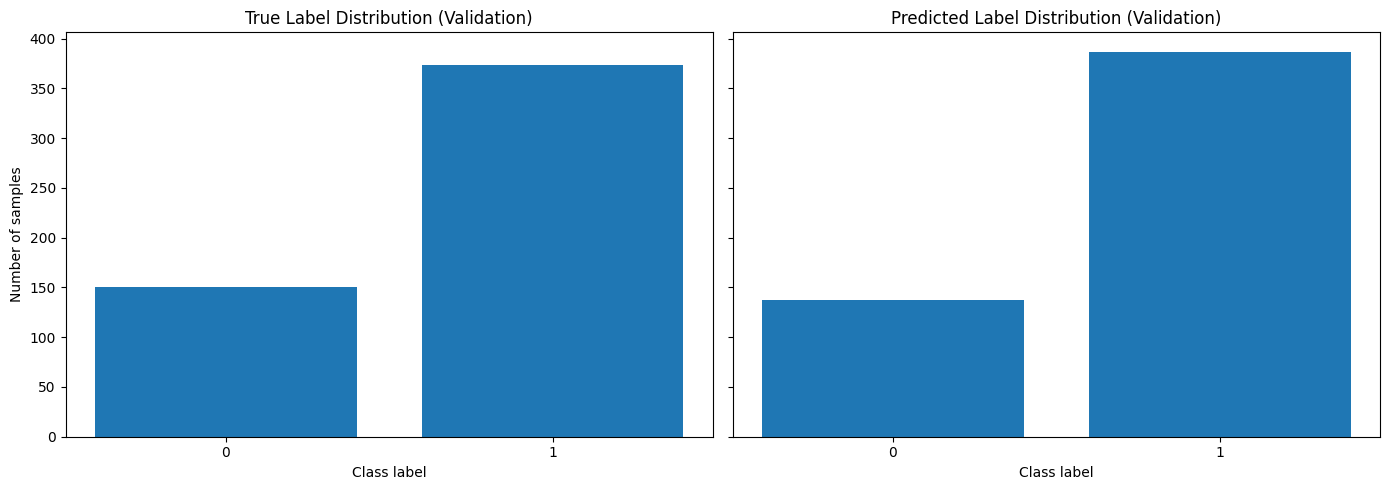

In [ ]:
# @title
num_classes = 2
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## (3) 2nd Vit classifier

In [ ]:
# @title
from VitClassifier_2_definitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_2_stage2_best_2_cat.pt"

model = ViTClassifierCLSPool(num_classes=2).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.8129770755767822


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group(y_true_age, y_pred_age, age_groups)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group(y_true_n, y_pred_n, gender)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group(y_true_n, y_pred_n, skin)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.333333  0.187500       22
1  41-49  0.809524  0.310345       50
2  51-59  0.878788  0.437500       98
3  61-69  0.971698  0.680000      131
4  71-79  0.941667  0.592593      147
5    <30  0.000000  0.222222       10
6    >80  0.925926  0.600000       64

Age EO Gap
0.3220698306311128

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.882759  0.405405      219
1    male  0.938865  0.486842      305

Gender EO Gap
0.068771353994529

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  1.000000  0.500000       11
1     2  0.818182  0.214286       50
2     3  0.942149  0.560000      317
3     4  0.870130  0.400000      107
4     5  0.892857  0.363636       39

Skin EO Gap
0.126344746162928

Generalized Fairness Score
0.8276046897371434


In [ ]:
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

logits = logits.cpu()
y_true = y_true.cpu()

probs = torch.softmax(logits, dim=1)
pos_probs = probs[:, 1].numpy()
y_true_np = y_true.numpy()

# Accuracy
y_pred = probs.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()

# ROC-AUC
roc_auc = roc_auc_score(y_true_np, pos_probs)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, pos_probs)
pr_auc = auc(recall, precision)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation Accuracy: 0.8130
Validation ROC-AUC: 0.8268
Validation PR-AUC: 0.9026


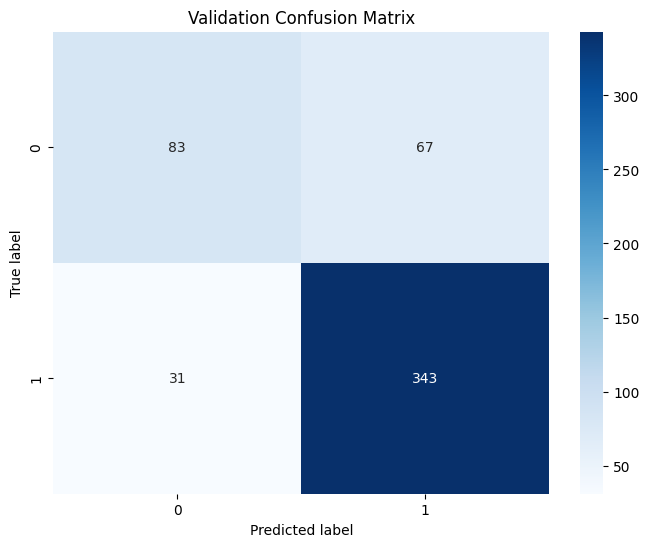

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.7281    0.5533    0.6288       150
           1     0.8366    0.9171    0.8750       374

    accuracy                         0.8130       524
   macro avg     0.7823    0.7352    0.7519       524
weighted avg     0.8055    0.8130    0.8045       524



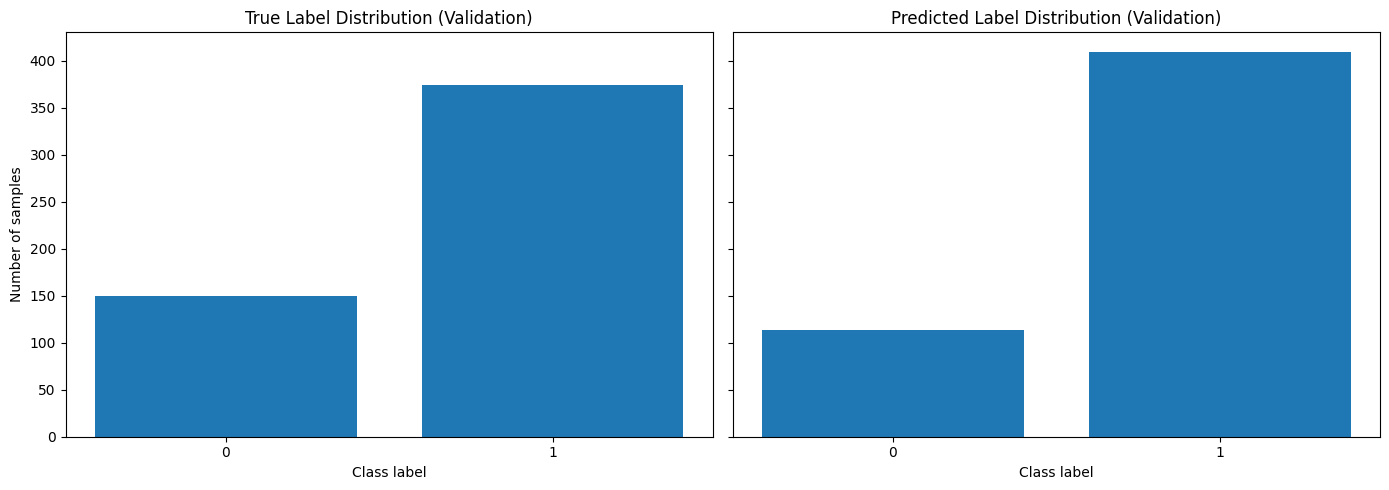

In [ ]:
# @title
num_classes = 2
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## (4) 3rd Vit classifier

In [ ]:
# @title
from VitClassifier_3_definitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_3_stage2_best_2_cat.pt"

model = ViTClassifierDeepHead(num_classes=2).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.7958015203475952


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group(y_true_age, y_pred_age, age_groups)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group(y_true_n, y_pred_n, gender)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group(y_true_n, y_pred_n, skin)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.833333  0.250000       22
1  41-49  0.809524  0.482759       50
2  51-59  0.924242  0.687500       98
3  61-69  0.971698  0.760000      131
4  71-79  0.975000  0.666667      147
5    <30  1.000000  0.444444       10
6    >80  0.925926  0.600000       64

Age EO Gap
0.14772555956262623

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.917241  0.513514      219
1    male  0.965066  0.644737      305

Gender EO Gap
0.08952372573240552

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  1.000000  0.500000       11
1     2  0.818182  0.500000       50
2     3  0.962810  0.613333      317
3     4  0.948052  0.566667      107
4     5  0.892857  0.636364       39

Skin EO Gap
0.08196497441951985

Generalized Fairness Score
0.8935952467618161


In [ ]:
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

logits = logits.cpu()
y_true = y_true.cpu()

probs = torch.softmax(logits, dim=1)
pos_probs = probs[:, 1].numpy()
y_true_np = y_true.numpy()

# Accuracy
y_pred = probs.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()

# ROC-AUC
roc_auc = roc_auc_score(y_true_np, pos_probs)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, pos_probs)
pr_auc = auc(recall, precision)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation Accuracy: 0.7958
Validation ROC-AUC: 0.8352
Validation PR-AUC: 0.9187


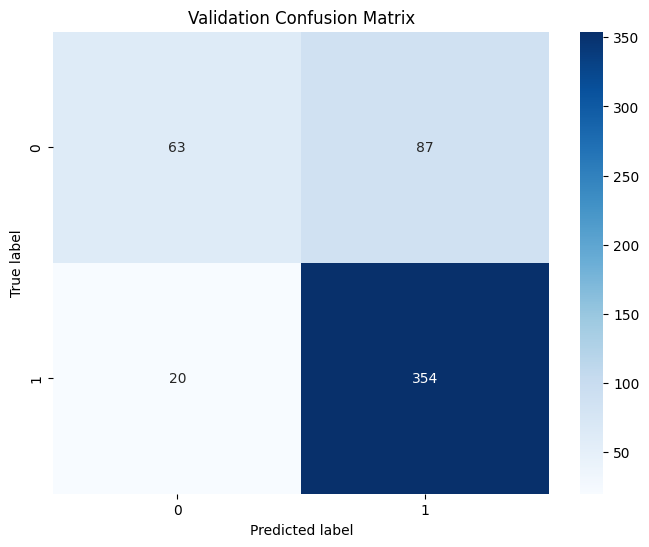

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.7590    0.4200    0.5408       150
           1     0.8027    0.9465    0.8687       374

    accuracy                         0.7958       524
   macro avg     0.7809    0.6833    0.7047       524
weighted avg     0.7902    0.7958    0.7748       524



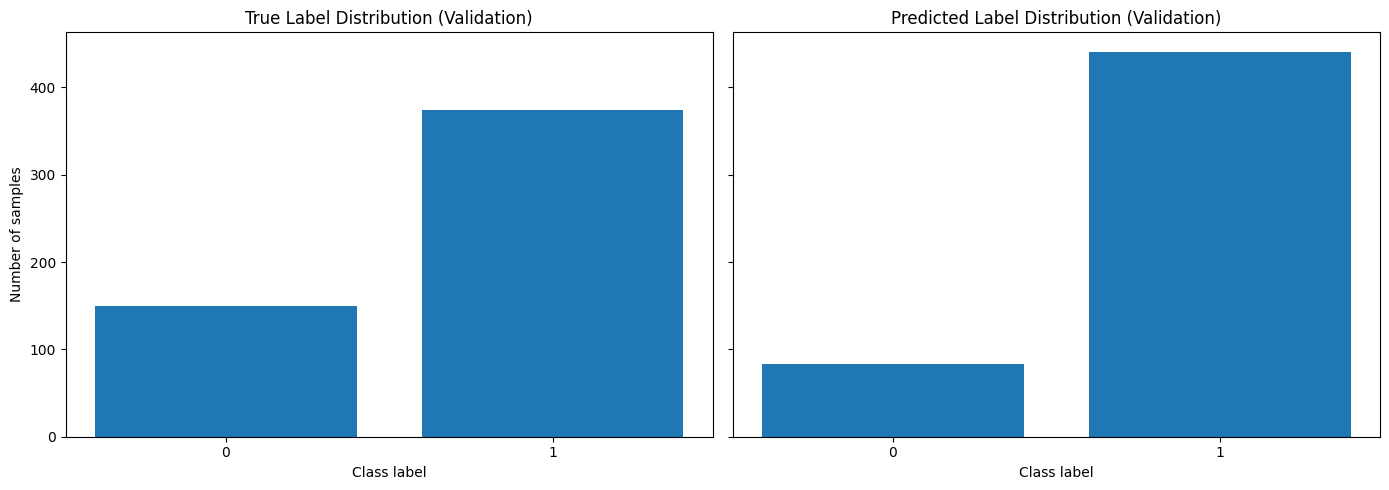

In [ ]:
# @title
num_classes = 2
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

I think the first ViT claassifier is by far the better, but I need to analyze more.

But then in the sense of Medical images, I would rather chose something that gives less false negatives, no?

# Conclusion for the Validation set


# 11 categories -> the labels of each skin lession
<table border="1">
  <tr>
    <th>Model</th>
    <th>Val Accuracy<br>(overall accuracy)</th>
    <th>Top-3 Acc<br>(percentage correct in top 3)</th>
    <th>Macro Avg F1<br>(mean F1 across classes)</th>
    <th>Weighted Avg F1<br>(F1 weighted by class support)</th>
    <th>Classes Missed<br>(precision=0 for these)</th>
    <th>Notes</th>
  </tr>
  <tr>
    <td>ResNet50_1</td>
    <td>0.6546</td>
    <td>0.9275</td>
    <td>0.4335</td>
    <td>0.6250</td>
    <td>5</td>
    <td>Good on major classes, minor classes partially missed</td>
  </tr>
  <tr>
    <td>ResNet18_1</td>
    <td>0.6469</td>
    <td>0.9256</td>
    <td>0.3253</td>
    <td>0.6050</td>
    <td>2,5,10</td>
    <td>Lower macro F1, some minor classes missed</td>
  </tr>
  <tr>
    <td>ViT_1</td>
    <td>0.6756</td>
    <td>0.9122</td>
    <td>0.4501</td>
    <td>0.6430</td>
    <td>5</td>
    <td>Best overall accuracy, minor classes missing</td>
  </tr>
  <tr>
    <td>ViT_2</td>
    <td>0.6584</td>
    <td>0.9256</td>
    <td>0.4170</td>
    <td>0.5933</td>
    <td>5</td>
    <td>Minor classes missing (5), slightly lower accuracy than ViT_1</td>
  </tr>
  <tr>
    <td>ViT_3</td>
    <td>0.6489</td>
    <td>0.9122</td>
    <td>0.3619</td>
    <td>0.5988</td>
    <td>5,10</td>
    <td>Minor classes missing (5), lower accuracy than ViT_1</td>
  </tr>
</table>

## Best ResNet classifier for 11 categories:

ResNet 50

**Description:**

The ResNet50 classifier is based on the pretrained ResNet50 architecture from torchvision,
initialized with ImageNet weights. Transfer learning was used in order to leverage the
feature extraction capabilities of a model trained on a large-scale dataset.

The original fully connected classification layer of the pretrained network was removed
and replaced with a custom classification head. The backbone outputs a feature vector
which is then passed to a multi-layer classifier composed of:

• Linear layer (2048 → 512)
• Batch Normalization
• ReLU activation
• Dropout regularization

followed by:

• Linear layer (512 → 128)
• Batch Normalization
• ReLU activation
• Dropout regularization

and finally:

• Linear layer (128 → num_classes)

This custom head allows the model to adapt the high-level features extracted by ResNet50
to the skin lesion classification task.

During training, transfer learning was applied by first freezing the backbone parameters
and training only the classification head. Afterwards, the backbone was unfrozen and the
entire network was fine-tuned.

Training used the CrossEntropyLoss function and the AdamW optimizer.

Hyperparameters were optimized using Optuna, performing a search over the learning rates
for both the classifier head and the full network:

• Learning rate (classifier head): 1e-4 – 1e-3  
• Learning rate (full network fine-tuning): 1e-5 – 1e-4  

The best performing configuration obtained from the search used:

• Head learning rate: 9.97 × 10⁻⁴  
• Full network learning rate: 7.34 × 10⁻⁵  
• Batch size: 32

Early stopping was applied based on validation loss with a patience of 10 epochs in order
to prevent overfitting.


## Best ViT classifier for 11 categories:
ViT 1st


**Description:**

Vision Transformer (ViT-B/16) Classifier

The Vision Transformer classifier is based on the pretrained ViT-B/16 architecture
from torchvision, initialized with ImageNet weights. Vision Transformers process
images as sequences of patches and use self-attention mechanisms to model
relationships between different regions of the image.

The original classification head of the pretrained ViT model was replaced with a
custom multi-layer classifier in order to adapt the network to the skin lesion
classification task.

The new classification head consists of:

• Linear layer (768 → 512)
• Batch Normalization
• ReLU activation
• Dropout regularization

followed by:

• Linear layer (512 → 128)
• Batch Normalization
• ReLU activation
• Dropout regularization

and finally:

• Linear layer (128 → num_classes)

This design allows the transformer backbone to extract global image features
while the custom classifier learns task-specific representations for skin
lesion classification.

Transfer learning was applied during training. Initially, the transformer
backbone was frozen and only the classification head was trained. After this
stage, the backbone was unfrozen and the entire network was fine-tuned.

The model was trained using the CrossEntropyLoss function and the AdamW
optimizer.

Hyperparameters were optimized using Optuna, performing a search over the
learning rates for both the classification head and the full network:

• Learning rate (classifier head): 1e-4 – 1e-3  
• Learning rate (full network fine-tuning): 1e-5 – 1e-4  

The best performing configuration obtained from the search used:

• Head learning rate: 4.62 × 10⁻⁴  
• Full network learning rate: 1.15 × 10⁻⁵  
• Batch size: 32

Early stopping based on validation loss with a patience of 10 epochs was
used to prevent overfitting.



### Best classifier for 11 categroies from both:

The ViT 1st classifier performs overall best from all proposed models. Still it fails to classify class 5.

<table border="1">
  <tr>
    <th>Model</th>
    <th>Val Accuracy<br>(overall accuracy)</th>
    <th>Top-3 Acc<br>(percentage correct in top 3)</th>
    <th>Macro Avg F1<br>(mean F1 across classes)</th>
    <th>Weighted Avg F1<br>(F1 weighted by class support)</th>
    <th>Classes Missed<br>(precision=0 for these)</th>
    <th>Notes</th>
  </tr>
  <tr>
    <td>ViT_1</td>
    <td>0.6756</td>
    <td>0.9122</td>
    <td>0.4501</td>
    <td>0.6430</td>
    <td>5</td>
    <td>Best overall accuracy, minor classes missing</td>
  </tr>
</table>

# 2 categories -> Benign versus Malignant lessions

<table border="1">
  <tr>
    <th>Model</th>
    <th>Val Accuracy<br>(overall accuracy)</th>
    <th>Macro F1<br>(mean F1 across classes)</th>
    <th>Weighted F1<br>(F1 weighted by support)</th>
    <th>ROC-AUC<br>(area under ROC curve)</th>
    <th>PR-AUC<br>(area under Precision-Recall curve)</th>
    <th>Classes Missed<br>(precision=0)</th>
    <th>Notes</th>
  </tr>
  <tr>
    <td>ResNet50_1</td>
    <td>0.8015</td>
    <td>0.7454</td>
    <td>0.7965</td>
    <td>0.8336</td>
    <td>0.9109</td>
    <td>None</td>
    <td>Good balance, class 1 slightly favored</td>
  </tr>
  <tr>
    <td>ResNet18_1</td>
    <td>0.8092</td>
    <td>0.7646</td>
    <td>0.8084</td>
    <td>0.8470</td>
    <td>0.9243</td>
    <td>None</td>
    <td>Best overall accuracy and macro F1</td>
  </tr>
  <tr>
    <td>ViT_1</td>
    <td>0.8034</td>
    <td>0.7529</td>
    <td>0.8007</td>
    <td>0.8341</td>
    <td>0.9154</td>
    <td>None</td>
    <td>Good performance, slightly lower accuracy than ResNet18_1</td>
  </tr>
  <tr>
    <td>ViT_2</td>
    <td>0.8130</td>
    <td>0.7519</td>
    <td>0.8045</td>
    <td>0.8268</td>
    <td>0.9030</td>
    <td>None</td>
    <td>Best accuracy among ViT models, PR-AUC slightly lower</td>
  </tr>
  <tr>
    <td>ViT_3</td>
    <td>0.7958</td>
    <td>0.7047</td>
    <td>0.7748</td>
    <td>0.8352</td>
    <td>0.9189</td>
    <td>None</td>
    <td>Lower macro F1 due to class 0 underprediction</td>
  </tr>
</table>


## Best ResNet classifier for 2 categories:

ResNet 18

**Description:**

ResNet-18 Convolutional Neural Network Classifier

The ResNet-18 classifier is based on the pretrained ResNet-18 architecture
from torchvision, initialized with ImageNet weights. ResNet models are
convolutional neural networks that use residual connections to enable the
training of deeper architectures by allowing gradients to flow more easily
through the network.

The original fully connected classification layer of the pretrained ResNet-18
model was removed and replaced with a custom classifier designed for the skin
lesion classification task.

The new classification head consists of:

• Linear layer (512 → 512)
• Batch Normalization
• ReLU activation
• Dropout regularization

followed by:

• Linear layer (512 → 128)
• Batch Normalization
• ReLU activation
• Dropout regularization

and finally:

• Linear layer (128 → num_classes)

This architecture allows the convolutional backbone to extract hierarchical
image features while the custom classifier learns task-specific representations
for skin lesion classification.

Transfer learning was applied during training. Initially, the convolutional
backbone was frozen and only the classification head was trained. After this
stage, the backbone was unfrozen and the entire network was fine-tuned.

The model was trained using the CrossEntropyLoss function and the AdamW
optimizer.

Hyperparameters were optimized using Optuna, performing a search over the
learning rates for both the classification head and the full network:

• Learning rate (classifier head): 1e-4 – 1e-3  
• Learning rate (full network fine-tuning): 1e-5 – 1e-4  

The best performing configuration obtained from the search used:

• Head learning rate: 4.71 × 10⁻⁴  
• Full network learning rate: 2.93 × 10⁻⁵  
• Batch size: 16

Early stopping based on validation loss with a patience of 10 epochs was
used to prevent overfitting.


## Best ViT classifier for 2 categories:

ViT 2nd

**Description:**

Vision Transformer (ViT-B/16) Classifier with CLS + Patch Pooling

The Vision Transformer classifier is based on the pretrained ViT-B/16
architecture from torchvision, initialized with ImageNet weights.
Vision Transformers divide the input image into fixed-size patches
(16×16 pixels), which are embedded and processed by a transformer
encoder that models global relationships between image regions.

Instead of using only the standard CLS token representation, this model
combines two feature representations from the transformer encoder:

• the CLS token output, which summarizes the global image representation  
• the mean-pooled representation of all patch tokens

These two feature vectors are concatenated to form a richer image
representation before classification.

The final classification head consists of:

• Layer Normalization  
• Linear layer (hidden_dim × 2 → 256)  
• GELU activation  
• Dropout regularization  
• Linear layer (256 → num_classes)

This approach improves robustness by combining global contextual
information (CLS token) with aggregated local patch information.

Transfer learning was applied during training. Initially, the Vision
Transformer backbone was frozen and only the classification head was
trained. After this stage, the entire model was unfrozen and fine-tuned.

The model was trained using the CrossEntropyLoss function and the AdamW
optimizer.

Hyperparameters were optimized using Optuna, performing a search over
the learning rates for both the classifier head and the full network.

The best performing configuration obtained from the search used:

• Head learning rate: 2.98 × 10⁻⁴  
• Full network learning rate: 1.55 × 10⁻⁵  
• Batch size: 32

Early stopping based on validation loss with a patience of 10 epochs
was used to prevent overfitting.



### Best classifier for 2 categroies from both:

ResNet 18 version

<table border="1">
  <tr>
    <th>Model</th>
    <th>Val Accuracy<br>(overall accuracy)</th>
    <th>Macro F1<br>(mean F1 across classes)</th>
    <th>Weighted F1<br>(F1 weighted by support)</th>
    <th>ROC-AUC<br>(area under ROC curve)</th>
    <th>PR-AUC<br>(area under Precision-Recall curve)</th>
    <th>Classes Missed<br>(precision=0)</th>
    <th>Notes</th>
  </tr>
  <tr>
    <td>ResNet18_1</td>
    <td>0.8092</td>
    <td>0.7646</td>
    <td>0.8084</td>
    <td>0.8470</td>
    <td>0.9243</td>
    <td>None</td>
    <td>Best overall accuracy and macro F1</td>
  </tr>
</table>

# TEST set performance:



## For 11 categories (ResNet 50 (Fairest) and ViT 1st (Best Accuracy))

### Load the test set

In [ ]:
# @title
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

from utils import load_lesion_splits

_, _ , test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Test: {len(test_lesions)}"
)


# Validation
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

Test: 525


In [ ]:
# @title
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from utils import Milk10kDataset_unimodal
from torch.utils.data import DataLoader
import os

test_transform = transforms.Compose([
    transforms.ToTensor()])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

test_dataset   = Milk10kDataset_unimodal(df_test_clinical,
                                        DATASET_RESIZED + "/test",
                                        transform=test_transform)

NUM_WORKERS = os.cpu_count()

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader

Using device: cpu


### Load the metadata for the

In [ ]:
import numpy as np

ages = df_test_clinical["age_approx"].values
print(df_test_clinical["age_approx"].value_counts())
ages = df_test_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_test_clinical["sex"].values


skin_df = df_test_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
70.0    74
65.0    74
75.0    62
55.0    57
60.0    45
50.0    45
80.0    41
85.0    34
45.0    27
40.0    19
35.0    14
30.0    12
20.0     7
25.0     4
5.0      4
10.0     3
15.0     1
Name: count, dtype: int64
<30       19
31-39     26
41-49     46
51-59    102
61-69    119
71-79    136
>80       75
Name: count, dtype: int64
0      3
1     19
2     58
3    294
4    103
5     48
Name: count, dtype: int64
0-1     22
2       58
3      294
4      103
5       48
Name: count, dtype: int64


## 1. ResNet 50 (Fairest):

In [ ]:
# @title
from ResNet50_1_definitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load the model as saved in the checkpoints dir:
model = ResNet50Classifier(num_classes=11).to(device)

checkpoint_path = CHECKPOINT_DIR + "/RESNET_1_best_stage2.pt"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

Using device: cpu


<All keys matched successfully>

In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"test accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


test accuracy: 0.6133333444595337


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_test_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.364286  0.060476       26
1  41-49  0.286923  0.047439       46
2  51-59  0.286325  0.052425      102
3  61-69  0.294626  0.053312      119
4  71-79  0.277754  0.053928      136
5    <30  0.400000  0.034290       19
6    >80  0.278639  0.054574       75

Age EO Gap
0.03050781865037035

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.314589  0.045785      218
1    male  0.288615  0.053461      307

Gender EO Gap
0.016825578300135192

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.431818  0.067316       22
1     2  0.239072  0.058766       58
2     3  0.315841  0.046845      294
3     4  0.310139  0.045884      103
4     5  0.146667  0.071931       48

Skin EO Gap
0.07196380938235483

Generalized Fairness Score
0.9602342645557133


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 28 samples
Class 1 has 231 samples
Class 2 has 14 samples
Class 3 has 49 samples
Class 4 has 13 samples
Class 5 has 14 samples
Class 6 has 9 samples
Class 7 has 40 samples
Class 8 has 68 samples
Class 9 has 48 samples
Class 10 has 11 samples
PR-AUC per class: [np.float64(0.21878970173731208), np.float64(0.8449477286920852), np.float64(0.154899826731455), np.float64(0.2838788451522528), np.float64(0.21383098746876644), np.float64(0.059817743119421556), np.float64(0.027969245260049822), np.float64(0.38125243203937903), np.float64(0.7441043118482684), np.float64(0.6164729262761948), np.float64(0.24265583768166288)]
Validation PR-AUC (weighted): 0.6083
Validation PR-AUC (macro): 0.3444


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.3333    0.1071    0.1622        28
           1     0.6830    0.9048    0.7784       231
           2     1.0000    0.0714    0.1333        14
           3     0.3542    0.3469    0.3505        49
           4     0.2000    0.0769    0.1111        13
           5     0.0000    0.0000    0.0000        14
           6     0.0000    0.0000    0.0000         9
           7     0.5000    0.4250    0.4595        40
           8     0.6528    0.6912    0.6714        68
           9     0.5306    0.5417    0.5361        48
          10     1.0000    0.0909    0.1667        11

    accuracy                         0.6133       525
   macro avg     0.4776    0.2960    0.3063       525
weighted avg     0.5751    0.6133    0.5646       525

Top-3 Accuracy: 0.8457


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## ViT 1 (Best Overall Accuracy):

In [ ]:
# @title
from VitClassifier_1_defnitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load the model as saved in the checkpoints dir:
model = ViTClassifier(num_classes=11).to(device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_1_best_stage2.pt"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

Using device: cpu


<All keys matched successfully>

In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"test accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


test accuracy: 0.6380952596664429


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_test_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.275000  0.056753       26
1  41-49  0.340000  0.042116       46
2  51-59  0.274786  0.056179      102
3  61-69  0.316192  0.047735      119
4  71-79  0.300870  0.054136      136
5    <30  0.466667  0.029506       19
6    >80  0.273797  0.055280       75

Age EO Gap
0.04131633708024341

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.349010  0.039661      218
1    male  0.294894  0.054949      307

Gender EO Gap
0.03470174511532295

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.318182  0.080519       22
1     2  0.233238  0.060392       58
2     3  0.337858  0.047396      294
3     4  0.445556  0.039386      103
4     5  0.208333  0.058464       48

Skin EO Gap
0.06743278579036767

Generalized Fairness Score
0.9521830440046887


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Test PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Test PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 28 samples
Class 1 has 231 samples
Class 2 has 14 samples
Class 3 has 49 samples
Class 4 has 13 samples
Class 5 has 14 samples
Class 6 has 9 samples
Class 7 has 40 samples
Class 8 has 68 samples
Class 9 has 48 samples
Class 10 has 11 samples
PR-AUC per class: [np.float64(0.3399193228593599), np.float64(0.783581743601079), np.float64(0.18215586000623699), np.float64(0.2910124805792574), np.float64(0.22713487267395832), np.float64(0.09551887023954464), np.float64(0.019876989664609844), np.float64(0.44539513582641177), np.float64(0.7643265676603007), np.float64(0.5888609933065988), np.float64(0.2370732643081763)]
Validation PR-AUC (weighted): 0.5952
Validation PR-AUC (macro): 0.3614


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.5000    0.2500    0.3333        28
           1     0.6782    0.9307    0.7847       231
           2     1.0000    0.0714    0.1333        14
           3     0.3704    0.2041    0.2632        49
           4     0.0000    0.0000    0.0000        13
           5     0.0000    0.0000    0.0000        14
           6     0.0000    0.0000    0.0000         9
           7     0.5484    0.4250    0.4789        40
           8     0.6170    0.8529    0.7160        68
           9     0.6667    0.5000    0.5714        48
          10     0.6000    0.2727    0.3750        11

    accuracy                         0.6381       525
   macro avg     0.4528    0.3188    0.3323       525
weighted avg     0.5815    0.6381    0.5805       525

Top-3 Accuracy: 0.8381


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 2 categories (Best Overal Acc: ResNet18, Fairest: ViT3)

### Load the test set (for 2 categories)

In [ ]:
# @title
from utils import LABEL_COLUMNS, BENIGNANT_NAMES, MALIGNANT_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

def decode_label_id(row):
    for col in LABEL_COLUMNS:
        if row[col] == 1:
          # check if it is bening or malign:
          if col in BENIGNANT_NAMES:
            return 0
          if col in MALIGNANT_NAMES:
            return 1
    return "UNKNOWN"

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

from utils import load_lesion_splits

_, _ , test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/b_m_milk10k_lesion_splits.json"
)

print(
    f"Test: {len(test_lesions)}"
)

# Validation
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

Test: 524


In [ ]:
# @title
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from utils import Milk10kDataset_unimodal
from torch.utils.data import DataLoader
import os

test_transform = transforms.Compose([
    transforms.ToTensor()])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

test_dataset   = Milk10kDataset_unimodal(df_test_clinical,
                                        DATASET_RESIZED_B_M + "/test",
                                        transform=test_transform)

NUM_WORKERS = os.cpu_count()

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False, # important for fairness analysis
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader

Using device: cpu


In [ ]:
# @title
import numpy as np


ages = df_test_clinical["age_approx"].values
print(df_test_clinical["age_approx"].value_counts())
ages = df_test_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)

# Assume y_true is your true labels array for the test set
y_true = df_test_clinical["label_id"].values  # replace "target" with your label column

# Create boolean mask for <30 age group
mask_under_30 = age_groups == "<30"

# Count number of positives (class 1) in <30
num_positives_under_30 = np.sum(y_true[mask_under_30] == 1) #malignant
num_negatives_under_30 = np.sum(y_true[mask_under_30] == 0) #benign

print(f"<30 age group: {num_positives_under_30} positive samples, {num_negatives_under_30} negative samples, total {np.sum(mask_under_30)}")



#print(age_groups)
gender = df_test_clinical["sex"].values


skin_df = df_test_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
70.0    72
65.0    72
60.0    62
55.0    54
50.0    49
75.0    46
80.0    42
85.0    39
45.0    27
40.0    23
35.0    12
30.0    10
15.0     4
20.0     4
25.0     3
10.0     3
Name: count, dtype: int64
<30       14
31-39     22
41-49     50
51-59    103
61-69    134
71-79    118
>80       81
Name: count, dtype: int64
<30 age group: 0 positive samples, 14 negative samples, total 14
1     11
2     51
3    318
4    106
5     38
Name: count, dtype: int64
0-1     11
2       51
3      318
4      106
5       38
Name: count, dtype: int64


## ResNet 18 (Best overal accuracy)

In [ ]:
# @title
from ResNet18_1_definitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
checkpoint_path = CHECKPOINT_DIR + "/Resnet_2_stage2_best_2_cat.pt"

# load the model as saved in the checkpoints dir:
model = ResNet18Classifier(num_classes=2).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]


Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.830152690410614


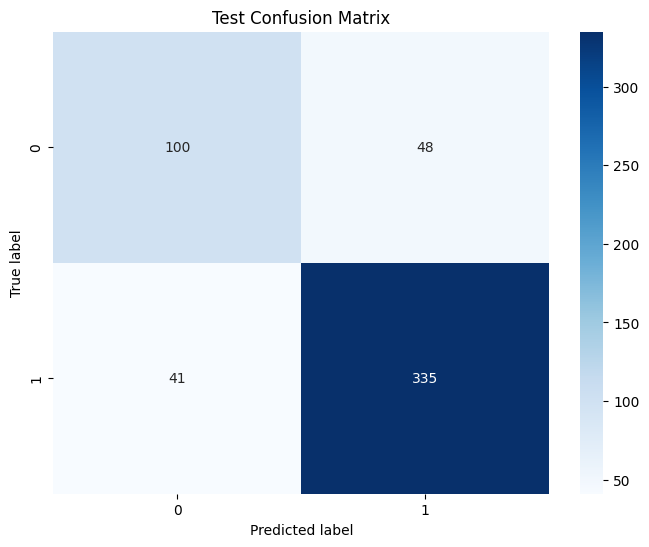

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test Confusion Matrix")
plt.show()

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)


valid_age_mask = ~df_test_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group(y_true_age, y_pred_age, age_groups)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap_nan_safe_2_cat(age_results, y_true_age, y_pred_age, age_groups)
print("\nAge EO Gap")
print(age_gap)


gender_results = equalized_odds_by_group(y_true_n, y_pred_n, gender)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group(y_true_n, y_pred_n, skin)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.600000  0.000000       22
1  41-49  0.736842  0.193548       50
2  51-59  0.876712  0.300000      103
3  61-69  0.933962  0.642857      134
4  71-79  0.908163  0.500000      118
5    <30       NaN  0.000000       14
6    >80  0.900000  0.454545       81

Skipping group '<30' due to NaN TPR/FPR. Confusion matrix:
TP: 0, FP: 0, TN: 14, FN: 0
Total samples: 14 (Pos: 0, Neg: 14)

Age EO Gap
0.2165082826552445

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.893617  0.285714      211
1    male  0.889362  0.358974      313

Gender EO Gap
0.03875769620450473

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.400000       11
1     2  0.565217  0.071429       51
2     3  0.921811  0.426667      318
3     4  0.881579  0.300000      106
4     5  0.964286  0.300000       38

Skin EO Gap
0.18637568693607345

Generalized Fairness Score
0.8527861114013925


In [ ]:
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

logits = logits.cpu()
y_true = y_true.cpu()

probs = torch.softmax(logits, dim=1)
pos_probs = probs[:, 1].numpy()
y_true_np = y_true.numpy()

# Accuracy
y_pred = probs.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()

# ROC-AUC
roc_auc = roc_auc_score(y_true_np, pos_probs)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, pos_probs)
pr_auc = auc(recall, precision)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation Accuracy: 0.8302
Validation ROC-AUC: 0.8580
Validation PR-AUC: 0.9188


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.7092    0.6757    0.6920       148
           1     0.8747    0.8910    0.8827       376

    accuracy                         0.8302       524
   macro avg     0.7919    0.7833    0.7874       524
weighted avg     0.8279    0.8302    0.8289       524



## ViT 3rd (Fairest)

In [ ]:
# @title
from VitClassifier_3_definitions import *

import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint_path = f"{CHECKPOINT_DIR}/vit_3_stage2_best_2_cat.pt"

model = ViTClassifierDeepHead(num_classes=2).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state"])
history = checkpoint["history"]

Using device: cpu


In [ ]:
# @title
from utils import run_inference, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.8206107020378113


In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)


valid_age_mask = ~df_test_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group(y_true_age, y_pred_age, age_groups)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap_nan_safe_2_cat(age_results, y_true_age, y_pred_age, age_groups)
print("\nAge EO Gap")
print(age_gap)


gender_results = equalized_odds_by_group(y_true_n, y_pred_n, gender)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group(y_true_n, y_pred_n, skin)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.800000  0.250000       22
1  41-49  0.842105  0.419355       50
2  51-59  0.958904  0.500000      103
3  61-69  0.990566  0.821429      134
4  71-79  0.979592  0.850000      118
5    <30       NaN  0.071429       14
6    >80  0.957143  0.727273       81

Skipping group '<30' due to NaN TPR/FPR. Confusion matrix:
TP: 0, FP: 1, TN: 13, FN: 0
Total samples: 14 (Pos: 0, Neg: 14)

Age EO Gap
0.19335150290950784

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.964539  0.457143      211
1    male  0.961702  0.615385      313

Gender EO Gap
0.0805393188371912

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  1.000000  0.600000       11
1     2  0.826087  0.357143       51
2     3  0.975309  0.640000      318
3     4  0.960526  0.500000      106
4     5  0.964286  0.400000       38

Skin EO Gap
0.11283226988566424

Generalized Fairness Score
0.8710923027892122


In [ ]:
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

logits = logits.cpu()
y_true = y_true.cpu()

probs = torch.softmax(logits, dim=1)
pos_probs = probs[:, 1].numpy()
y_true_np = y_true.numpy()

# Accuracy
y_pred = probs.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()

# ROC-AUC
roc_auc = roc_auc_score(y_true_np, pos_probs)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_true_np, pos_probs)
pr_auc = auc(recall, precision)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation Accuracy: 0.8206
Validation ROC-AUC: 0.8332
Validation PR-AUC: 0.9049


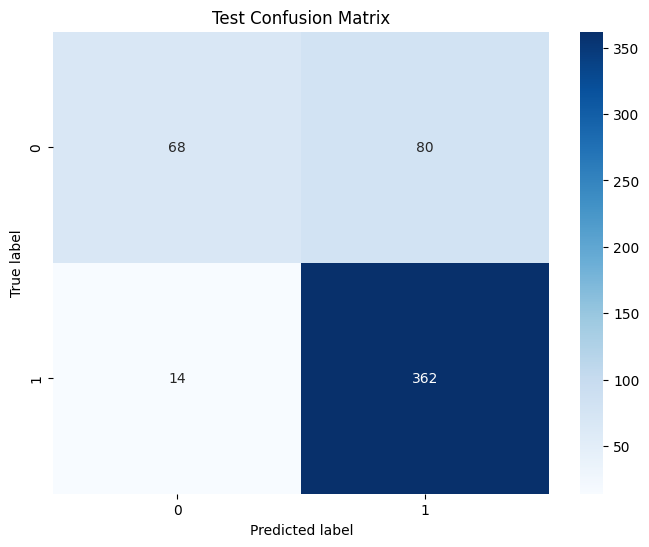

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test Confusion Matrix")
plt.show()

In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.8293    0.4595    0.5913       148
           1     0.8190    0.9628    0.8851       376

    accuracy                         0.8206       524
   macro avg     0.8241    0.7111    0.7382       524
weighted avg     0.8219    0.8206    0.8021       524



# 2 MULTIMODAL: 11 categories

## 2.1 Image + full metadata

## VALIDATION


## Load data:

In [37]:
# @title
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
sys.path.append(WORK_DIR_ROOT)

from utils import *
from VitClassifier_1_defnitions import *



DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
#DATASET_TRAIN_ZIP = f"{DATASET_ROOT}/MILK10k_Training_Input.zip"
DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/datasets_resized_stratified/"
DATASET_RESIZED_B_M = f"{WORK_DIR_ROOT}/mal_ben_datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"


CHECKPOINT_DIR = WORK_DIR_ROOT + 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

,lesion_id,isic_id,image_type,age_approx,sex,skin_tone_class,site,label_id
0,IL_0000652,ISIC_8149219,clinical: close-up,70.0,male,1,head_neck_face,1
1,IL_0003176,ISIC_3904045,clinical: close-up,45.0,female,5,head_neck_face,1
2,IL_0004688,ISIC_0791494,clinical: close-up,50.0,male,3,lower_extremity,1
3,IL_0005081,ISIC_5667730,clinical: close-up,45.0,male,3,head_neck_face,9
4,IL_0006177,ISIC_8803389,clinical: close-up,75.0,male,3,upper_extremity,1


#### Load the lession_ids for val/test stratified datasets

In [39]:
from utils import load_lesion_splits

_, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Val: 524, Test: 525


#### Get metadata one-hot soft encoding:

In [40]:
metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


#### Create data loaders with a custom dataset class

For this purpose, use a custom Dataset called Milk10kDataset_multimodal, which receives a dataframe to read the metadata and labels from, a root directory to read the image files from, a custom transform to apply to the images. It assumes only one image type, so we filter beforehand.



#### Create the data transformers

In [41]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.ToTensor()])

#### Create the data loaders

In [42]:
from utils import Milk10kDataset_multimodal
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

val_dataset = Milk10kDataset_multimodal(
    df_val_clinical,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform,
    smoothing=0.1
)

test_dataset = Milk10kDataset_multimodal(
    df_test_clinical,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform,
    smoothing=0.1
)


NUM_WORKERS = os.cpu_count()

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader, val_loader

Using device: cpu


(<torch.utils.data.dataloader.DataLoader at 0x7a3b34923710>,
 <torch.utils.data.dataloader.DataLoader at 0x7a3b34922ba0>)

#### Labels of the samples, regarding the sensitive groups

In [43]:
import numpy as np

ages = df_val_clinical["age_approx"].values
print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-40", "41-50", "51-60", "61-70", "71-80", ">=81"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
65.0    75
70.0    66
50.0    61
75.0    56
60.0    53
55.0    50
85.0    42
80.0    37
45.0    37
40.0    15
35.0    12
30.0     9
15.0     5
25.0     4
5.0      1
Name: count, dtype: int64
<=30      19
31-40     27
41-50     98
51-60    103
61-70    141
71-80     93
>=81      42
Name: count, dtype: int64
1     11
2     50
3    319
4    107
5     37
Name: count, dtype: int64
0-1     11
2       50
3      319
4      107
5       37
Name: count, dtype: int64


### (1) Learned feature fusion (Image + full metadata) with Multiplication
Test ViT image encoder, metadta encoder and multiplication of embedings to fuse the inputs.

In [44]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = MultimodalModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/ViT_1_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 34


KeyboardInterrupt: 

#### Do more extensive analysis of the performance

In [11]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6679389476776123


### Utility:

In [12]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, val_loader, device)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4296
  Weighted PR-AUC: 0.6850


#### Equalized odds:

In [13]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.377778 0.045455         0.716214        0.226015       27
41-50 0.255829 0.050149         0.659654        0.219386       98
51-60 0.372664 0.049497         0.751733        0.187735      103
61-70 0.290408 0.049740         0.725425        0.204639      141
71-80 0.294895 0.056460         0.690006        0.203005       93
 <=30 0.500000 0.068182         0.795813        0.191860       19
 >=81 0.356602 0.054627         0.661118        0.206466       42

Age EO Gap: 0.05104837203247063

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.298881 0.045210         0.705042        0.213805      208
  male 0.290513 0.048481         0.711059        0.204338      316

Gender EO Gap: 0.005819276268447485

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.400000 0.071970         0.718152        0.189615       11


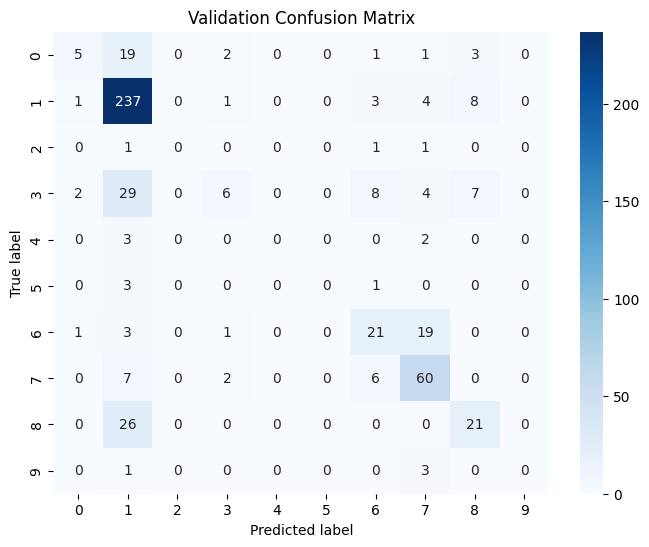

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.5556    0.1613    0.2500        31
           1     0.7204    0.9331    0.8130       254
           2     0.0000    0.0000    0.0000         3
           3     0.5000    0.1071    0.1765        56
           4     0.0000    0.0000    0.0000         5
           5     0.0000    0.0000    0.0000         4
           7     0.5122    0.4667    0.4884        45
           8     0.6383    0.8000    0.7101        75
           9     0.5385    0.4468    0.4884        47
          10     0.0000    0.0000    0.0000         4

    accuracy                         0.6679       524
   macro avg     0.3465    0.2915    0.2926       524
weighted avg     0.6191    0.6679    0.6151       524

Top-3 Accuracy: 0.9313


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.33829648022886694), np.float64(0.8723819093597253), np.float64(0.0501246054315108), np.float64(0.28736964880078797), np.float64(0.4030505773296471), np.float64(0.13341022611986184), np.float64(0.5), np.float64(0.4836310363556397), np.float64(0.7441966239335801), np.float64(0.6178259848635923), np.float64(0.3658322943173926)]
Validation PR-AUC (weighted): 0.6850
Validation PR-AUC (macro): 0.4360


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


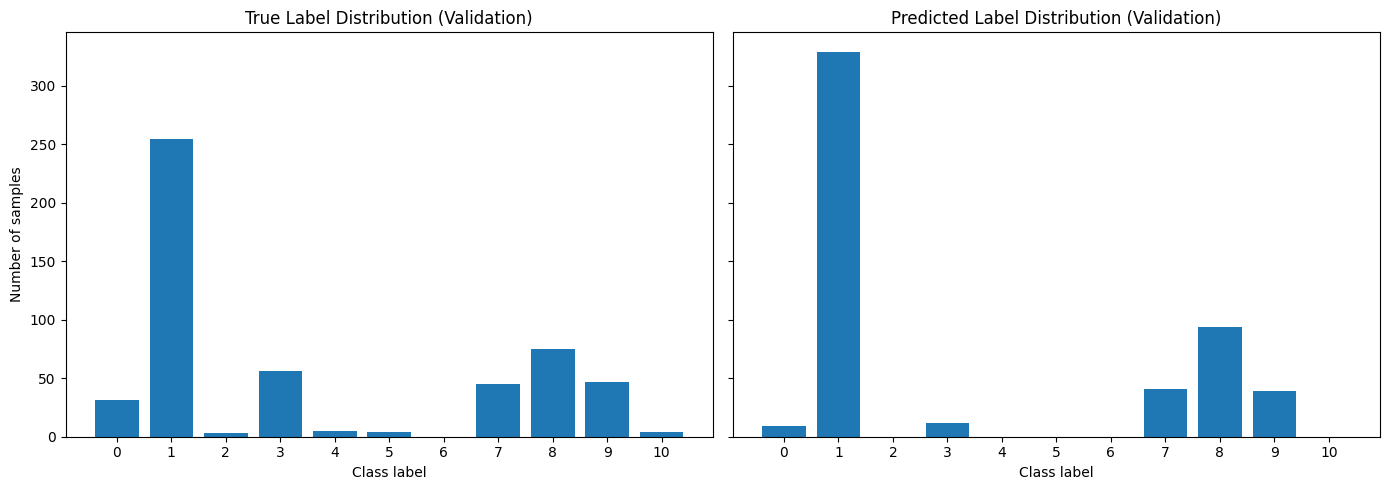

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

### (2) Learned feature fusion (Image + full metadata) with Concatenation
ViT with same metadata and fusion based on concatenation of embeddings

In [14]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = MultimodalModel_concat(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/ViT_2_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 34


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [15]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6545801758766174


### Utility:

In [16]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, val_loader, device)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4033
  Weighted PR-AUC: 0.6759


#### Equalized odds:

In [17]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.394444 0.044461         0.709451        0.226010       27
41-50 0.382713 0.051022         0.685788        0.200995       98
51-60 0.366919 0.049374         0.753812        0.193680      103
61-70 0.269032 0.052647         0.755713        0.204515      141
71-80 0.265728 0.056545         0.710818        0.183239       93
 <=30 0.466667 0.060903         0.809808        0.227440       19
 >=81 0.374459 0.052859         0.708204        0.180818       42

Age EO Gap: 0.0445209963811682

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.387848 0.047231         0.736795        0.199511      208
  male 0.281895 0.049170         0.726165        0.201669      316

Gender EO Gap: 0.05394594792514901

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.500000 0.063131         0.703051        0.179387       11
  

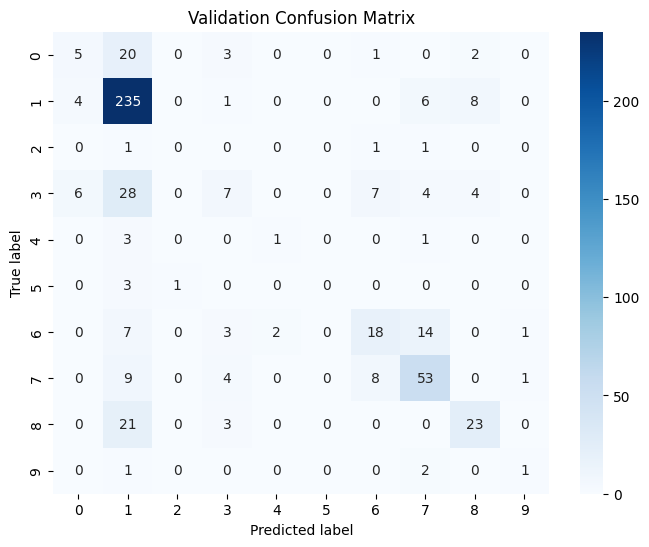

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.3333    0.1613    0.2174        31
           1     0.7165    0.9252    0.8076       254
           2     0.0000    0.0000    0.0000         3
           3     0.3333    0.1250    0.1818        56
           4     0.3333    0.2000    0.2500         5
           5     0.0000    0.0000    0.0000         4
           7     0.5143    0.4000    0.4500        45
           8     0.6543    0.7067    0.6795        75
           9     0.6216    0.4894    0.5476        47
          10     0.3333    0.2500    0.2857         4

    accuracy                         0.6546       524
   macro avg     0.3840    0.3258    0.3420       524
weighted avg     0.6019    0.6546    0.6133       524

Top-3 Accuracy: 0.9084


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.3417428260673675), np.float64(0.8562455866949695), np.float64(0.04909308603274121), np.float64(0.26141043863030883), np.float64(0.26772053083528496), np.float64(0.09628145602808492), np.float64(0.5), np.float64(0.45554415482168686), np.float64(0.759447313561477), np.float64(0.6587750239397662), np.float64(0.28694063990936935)]
Validation PR-AUC (weighted): 0.6759
Validation PR-AUC (macro): 0.4121


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


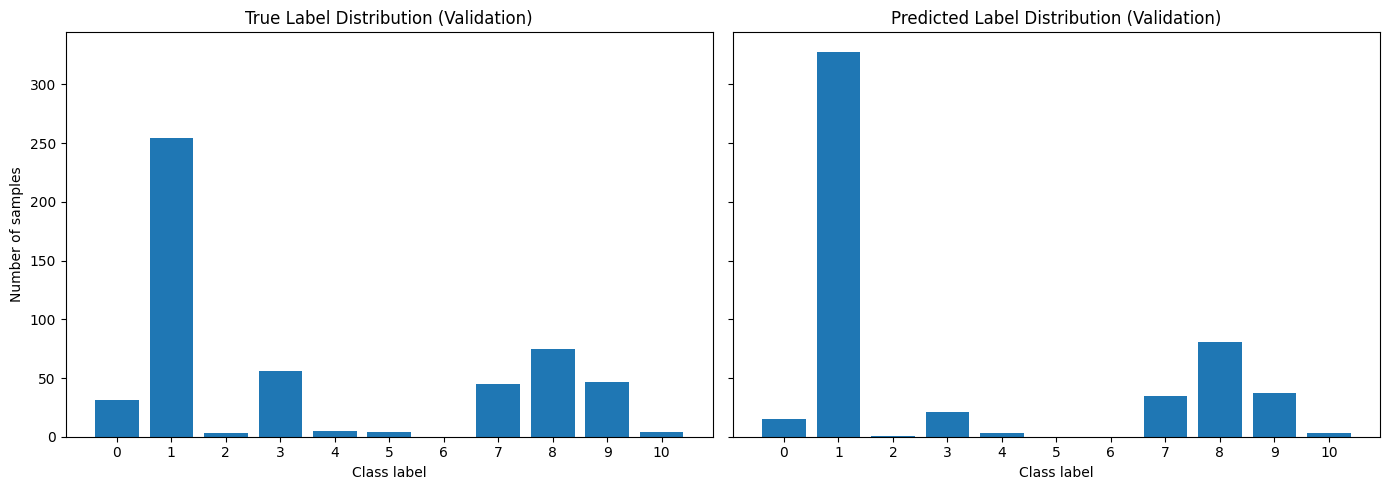

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

### (3) CrossAttention for Image + full metadata.

In [18]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_1_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 34


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [19]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6812977194786072


### Utility:

In [20]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, val_loader, device)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4523
  Weighted PR-AUC: 0.6903


#### Equalized odds:

In [21]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.300000 0.058923         0.655912        0.221549       27
41-50 0.372568 0.051031         0.653247        0.200386       98
51-60 0.455903 0.037303         0.712915        0.190959      103
61-70 0.398033 0.047681         0.725336        0.202316      141
71-80 0.352862 0.048911         0.704902        0.192504       93
 <=30 0.483333 0.073232         0.712326        0.175646       19
 >=81 0.373016 0.046776         0.675368        0.192787       42

Age EO Gap: 0.04366567119552302

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.358920 0.044913         0.698187        0.205022      208
  male 0.356758 0.042776         0.697278        0.195201      316

Gender EO Gap: 0.0021496192300258614

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.666667 0.040404         0.624635        0.129407       11

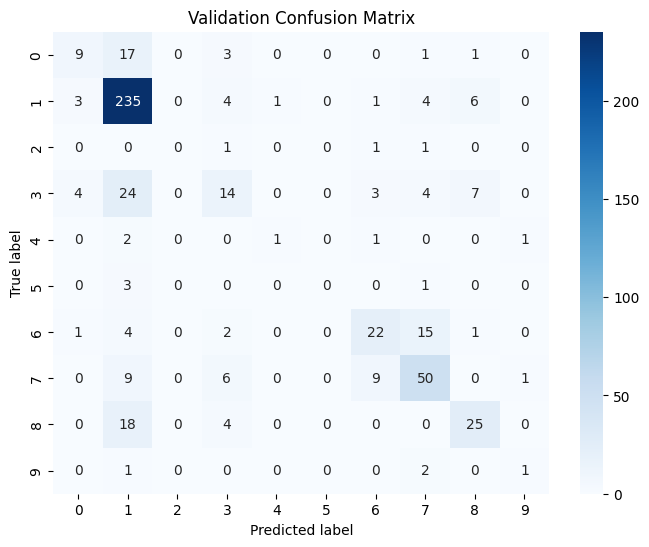

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.5294    0.2903    0.3750        31
           1     0.7508    0.9252    0.8289       254
           2     0.0000    0.0000    0.0000         3
           3     0.4118    0.2500    0.3111        56
           4     0.5000    0.2000    0.2857         5
           5     0.0000    0.0000    0.0000         4
           7     0.5946    0.4889    0.5366        45
           8     0.6410    0.6667    0.6536        75
           9     0.6250    0.5319    0.5747        47
          10     0.3333    0.2500    0.2857         4

    accuracy                         0.6813       524
   macro avg     0.4386    0.3603    0.3851       524
weighted avg     0.6454    0.6813    0.6533       524

Top-3 Accuracy: 0.9218


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.3449146160502574), np.float64(0.8623926494029801), np.float64(0.02358468906464687), np.float64(0.3310146234496555), np.float64(0.5368393113377704), np.float64(0.0749538065571135), np.float64(0.5), np.float64(0.6313455662607714), np.float64(0.6925300368457934), np.float64(0.6034840584398963), np.float64(0.4216690419911012)]
Validation PR-AUC (weighted): 0.6903
Validation PR-AUC (macro): 0.4566


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


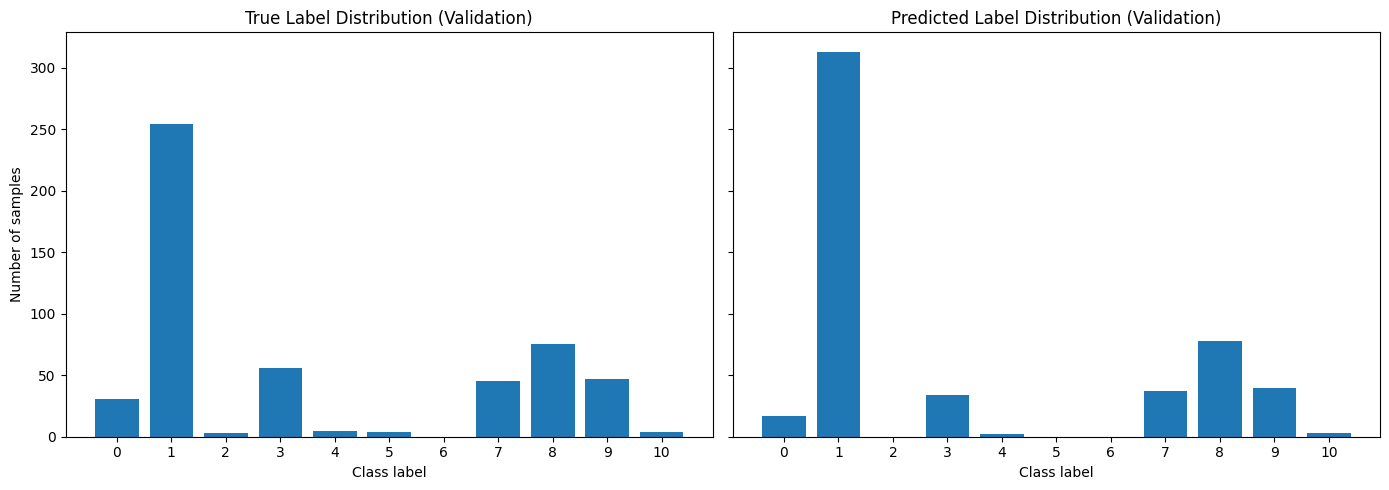

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

### (3 - 3) Cross attention images run 3

In [45]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_1_multimodal_best_run_3_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu
metadata input dimension: 34


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [46]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7003816962242126


### Utility:

In [47]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, val_loader, device)



PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4774
  Weighted PR-AUC: 0.6915


#### Equalized odds:

In [48]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.405556 0.040825         0.729526        0.207113       27
41-50 0.525622 0.042503         0.680919        0.222924       98
51-60 0.433838 0.039198         0.744154        0.207433      103
61-70 0.429892 0.041444         0.747524        0.196963      141
71-80 0.309089 0.052014         0.722873        0.205499       93
 <=30 0.716667 0.055853         0.759336        0.171586       19
 >=81 0.472583 0.035809         0.724238        0.179881       42

Age EO Gap: 0.07585697456676362

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.401343 0.041988         0.708385        0.210521      208
  male 0.449804 0.038977         0.740525        0.200892      316

Gender EO Gap: 0.025735823678592156

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.366667 0.070707         0.612092        0.186374       11


## TEST

#### Labels of the samples, regarding the sensitive groups

In [49]:
import numpy as np

ages = df_test_clinical["age_approx"].values
print(df_test_clinical["age_approx"].value_counts())
ages = df_test_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-40", "41-50", "51-60", "61-70", "71-80", ">=81"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_test_clinical["sex"].values


skin_df = df_test_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
70.0    74
65.0    74
75.0    62
55.0    57
60.0    45
50.0    45
80.0    41
85.0    34
45.0    27
40.0    19
35.0    14
30.0    12
20.0     7
25.0     4
5.0      4
10.0     3
15.0     1
Name: count, dtype: int64
<=30      31
31-40     33
41-50     72
51-60    102
61-70    148
71-80    103
>=81      34
Name: count, dtype: int64
0      3
1     19
2     58
3    294
4    103
5     48
Name: count, dtype: int64
0-1     22
2       58
3      294
4      103
5       48
Name: count, dtype: int64


## Test models:

### 1. (1) Learned fusion: Image + full metadata & Multiplication

In [23]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = MultimodalModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/ViT_1_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 34


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [24]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6133333444595337


### Utility:

In [27]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, test_loader, device)
y_pred = logits.argmax(dim=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3395
  Weighted PR-AUC: 0.6168


#### Equalized odds:

In [28]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.270833 0.058376         0.653100        0.259760       33
41-50 0.250000 0.053036         0.714706        0.205744       72
51-60 0.246599 0.055950         0.734921        0.205830      102
61-70 0.234381 0.054960         0.659320        0.202374      148
71-80 0.258179 0.060623         0.688953        0.196535      103
 <=30 0.333333 0.069697         0.788645        0.244827       31
 >=81 0.326531 0.063280         0.697982        0.173785       34

Age EO Gap: 0.026135600894104466

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.252805 0.049476         0.726805        0.214666      218
  male 0.252258 0.054072         0.677739        0.205608      307

Gender EO Gap: 0.002571527604885989

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.363636 0.075758         0.584923        0.179462       22

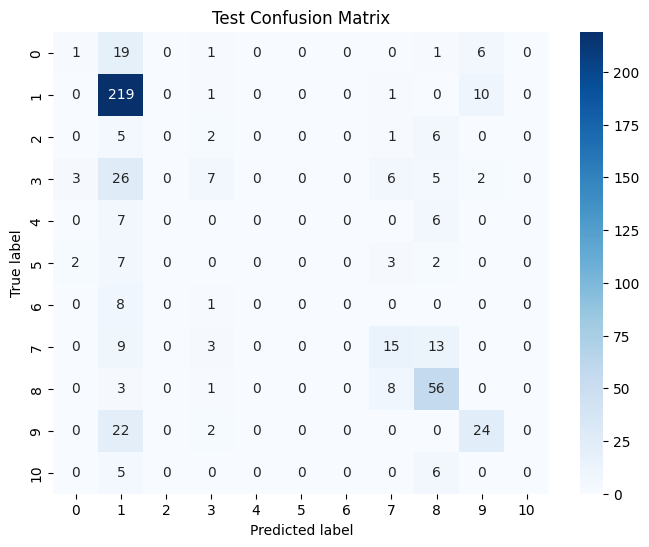

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.1667    0.0357    0.0588        28
           1     0.6636    0.9481    0.7807       231
           2     0.0000    0.0000    0.0000        14
           3     0.3889    0.1429    0.2090        49
           4     0.0000    0.0000    0.0000        13
           5     0.0000    0.0000    0.0000        14
           6     0.0000    0.0000    0.0000         9
           7     0.4412    0.3750    0.4054        40
           8     0.5895    0.8235    0.6871        68
           9     0.5714    0.5000    0.5333        48
          10     0.0000    0.0000    0.0000        11

    accuracy                         0.6133       525
   macro avg     0.2565    0.2568    0.2431       525
weighted avg     0.4994    0.6133    0.5348       525

Top-3 Accuracy: 0.8400


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Test PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Test PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 28 samples
Class 1 has 231 samples
Class 2 has 14 samples
Class 3 has 49 samples
Class 4 has 13 samples
Class 5 has 14 samples
Class 6 has 9 samples
Class 7 has 40 samples
Class 8 has 68 samples
Class 9 has 48 samples
Class 10 has 11 samples
PR-AUC per class: [np.float64(0.2450535993935688), np.float64(0.8514499751536421), np.float64(0.13023866877905405), np.float64(0.24805011738304034), np.float64(0.1899006977881051), np.float64(0.06036179337884498), np.float64(0.03247259419043688), np.float64(0.4068818573834886), np.float64(0.7964589857190234), np.float64(0.6417829057711675), np.float64(0.13187208551417753)]
Test PR-AUC (weighted): 0.6168
Test PR-AUC (macro): 0.3395


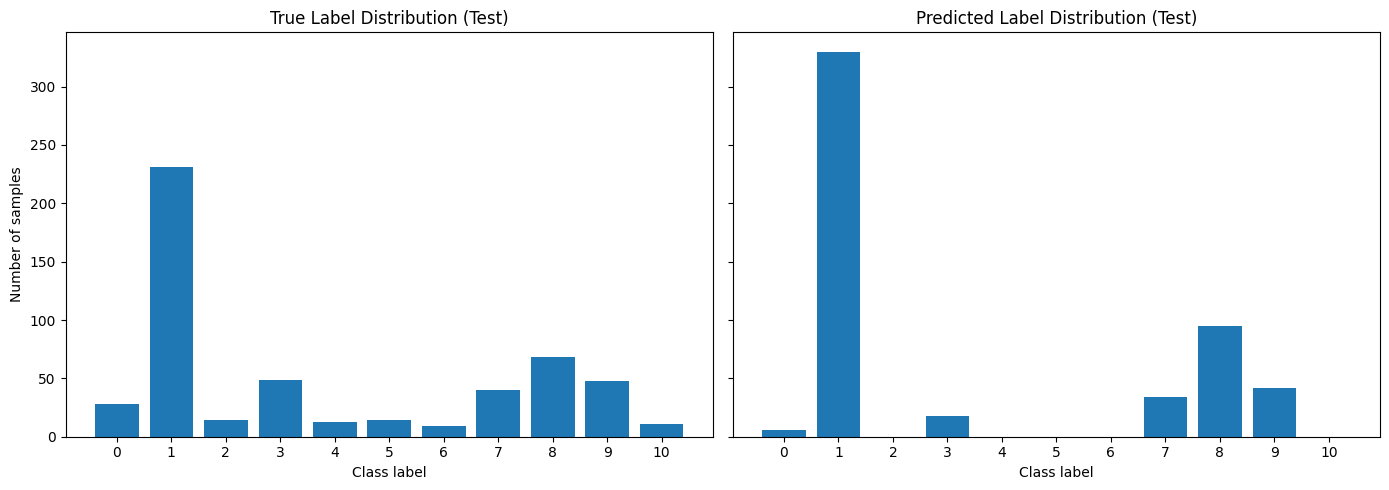

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Test)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Test)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

### 2. (3) Cross Attention: Image + full metadata

In [29]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_1_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 34


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [30]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6019047498703003


### Utility:

In [31]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, test_loader, device)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3516
  Weighted PR-AUC: 0.6101


#### Equalized odds:

In [32]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.301136 0.057803         0.606057        0.250159       33
41-50 0.413095 0.044126         0.689162        0.228822       72
51-60 0.229519 0.055806         0.709952        0.230554      102
61-70 0.236643 0.055598         0.690088        0.192093      148
71-80 0.263011 0.056427         0.678628        0.197665      103
 <=30 0.380952 0.069501         0.713847        0.202892       31
 >=81 0.161117 0.085068         0.660838        0.218992       34

Age EO Gap: 0.060758270858543365

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.288429 0.046013         0.701549        0.218654      218
  male 0.260631 0.055311         0.674784        0.210046      307

Gender EO Gap: 0.018548000375680634

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.272727 0.080087         0.516641        0.199640       22

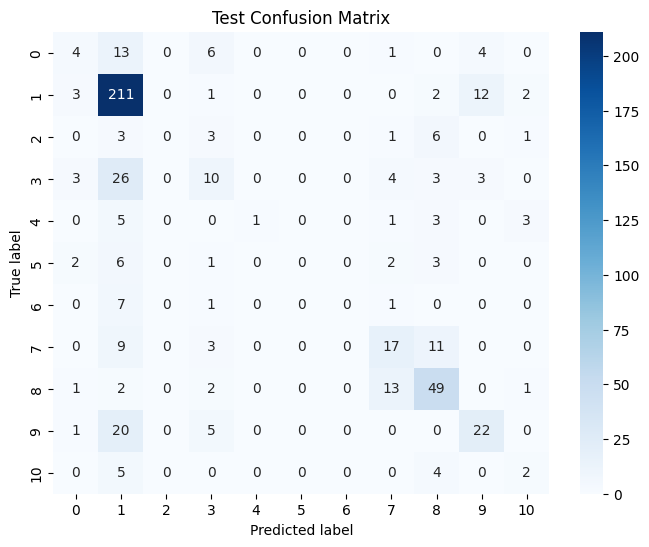

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.2857    0.1429    0.1905        28
           1     0.6873    0.9134    0.7844       231
           2     0.0000    0.0000    0.0000        14
           3     0.3125    0.2041    0.2469        49
           4     1.0000    0.0769    0.1429        13
           5     0.0000    0.0000    0.0000        14
           6     0.0000    0.0000    0.0000         9
           7     0.4250    0.4250    0.4250        40
           8     0.6049    0.7206    0.6577        68
           9     0.5366    0.4583    0.4944        48
          10     0.2222    0.1818    0.2000        11

    accuracy                         0.6019       525
   macro avg     0.3704    0.2839    0.2856       525
weighted avg     0.5360    0.6019    0.5488       525

Top-3 Accuracy: 0.8362


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Test PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Test PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 28 samples
Class 1 has 231 samples
Class 2 has 14 samples
Class 3 has 49 samples
Class 4 has 13 samples
Class 5 has 14 samples
Class 6 has 9 samples
Class 7 has 40 samples
Class 8 has 68 samples
Class 9 has 48 samples
Class 10 has 11 samples
PR-AUC per class: [np.float64(0.23135848615104562), np.float64(0.8459887548050955), np.float64(0.14817494234245215), np.float64(0.24323518387395174), np.float64(0.29774887061153543), np.float64(0.08306840295975079), np.float64(0.032560952119352234), np.float64(0.4539376579540056), np.float64(0.7558024851339842), np.float64(0.5668091151840748), np.float64(0.2088148902468884)]
Test PR-AUC (weighted): 0.6101
Test PR-AUC (macro): 0.3516


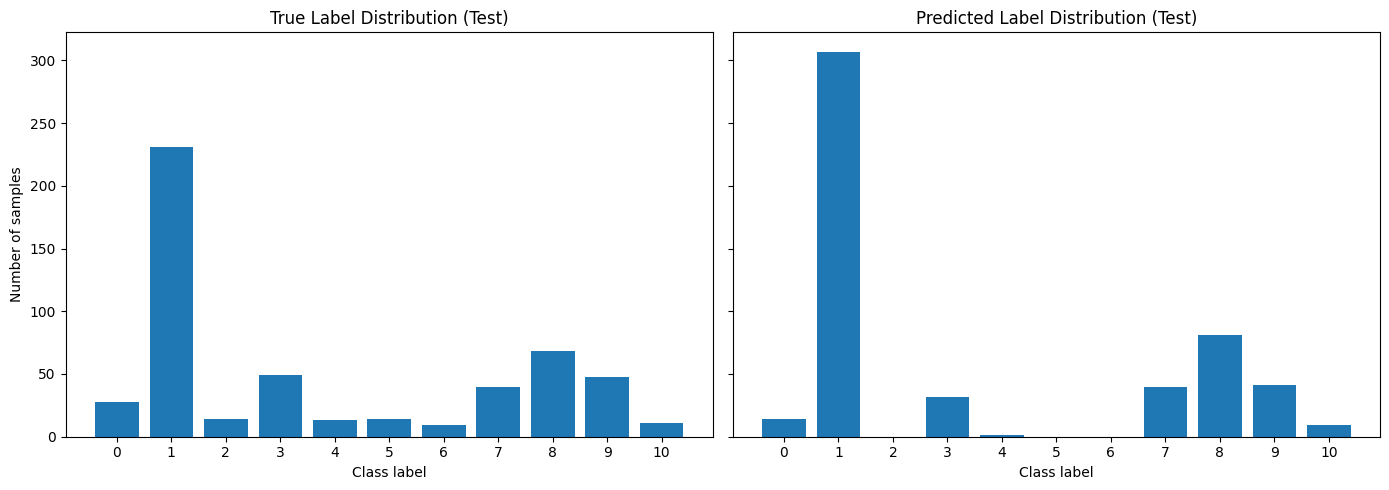

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Test)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Test)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

### (3 - 2) Cross attention images run 3

In [55]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(test_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_1_multimodal_best_run_2_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 34


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [56]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6266666650772095


### Utility:

In [57]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, test_loader, device)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3819
  Weighted PR-AUC: 0.6140


#### Equalized odds:

In [58]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.342803 0.054336         0.696408        0.192243       33
41-50 0.476190 0.041127         0.732185        0.214791       72
51-60 0.257512 0.051629         0.771844        0.198968      102
61-70 0.309045 0.051216         0.743799        0.189114      148
71-80 0.262031 0.052422         0.743979        0.186222      103
 <=30 0.333333 0.063636         0.771888        0.213926       31
 >=81 0.252954 0.073548         0.744544        0.216725       34

Age EO Gap: 0.04935254866343738

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.323310 0.044117         0.748502        0.200151      218
  male 0.315092 0.050458         0.743966        0.199224      307

Gender EO Gap: 0.007279412700492687

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.454545 0.062121         0.633232        0.173470       22


In [59]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.3333    0.1786    0.2326        28
           1     0.7047    0.9091    0.7940       231
           2     0.0000    0.0000    0.0000        14
           3     0.4074    0.2245    0.2895        49
           4     0.5000    0.3846    0.4348        13
           5     0.0000    0.0000    0.0000        14
           6     0.0000    0.0000    0.0000         9
           7     0.4634    0.4750    0.4691        40
           8     0.6667    0.7647    0.7123        68
           9     0.5200    0.5417    0.5306        48
          10     0.2500    0.0909    0.1333        11

    accuracy                         0.6267       525
   macro avg     0.3496    0.3245    0.3269       525
weighted avg     0.5527    0.6267    0.5788       525

Top-3 Accuracy: 0.8343


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### (3 - 3) Cross attention images run 3

In [50]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(test_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_1_multimodal_best_run_3_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 34


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [51]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6266666650772095


### Utility:

In [52]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, test_loader, device)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4020
  Weighted PR-AUC: 0.6342


#### Equalized odds:

In [53]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
  )


Age Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
31-40 0.301136 0.057178         0.667906        0.238349       33
41-50 0.301984 0.050324         0.733373        0.211104       72
51-60 0.260097 0.052872         0.740930        0.226981      102
61-70 0.337546 0.048559         0.699331        0.194055      148
71-80 0.354433 0.050181         0.721317        0.199550      103
 <=30 0.444444 0.045161         0.725461        0.237149       31
 >=81 0.284282 0.060734         0.712126        0.193766       34

Age EO Gap: 0.03792370646698068

Gender Equalized Odds
 group      TPR      FPR  mean_confidence  std_confidence  support
female 0.337529 0.041797         0.730805        0.219541      218
  male 0.337119 0.051860         0.707799        0.203583      307

Gender EO Gap: 0.005236722339924536

Skin Tone Equalized Odds
group      TPR      FPR  mean_confidence  std_confidence  support
  0-1 0.250000 0.080736         0.507931        0.178538       22


In [54]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.3333    0.1786    0.2326        28
           1     0.7075    0.9004    0.7924       231
           2     0.0000    0.0000    0.0000        14
           3     0.3421    0.2653    0.2989        49
           4     0.4286    0.2308    0.3000        13
           5     0.0000    0.0000    0.0000        14
           6     0.0000    0.0000    0.0000         9
           7     0.4419    0.4750    0.4578        40
           8     0.6986    0.7500    0.7234        68
           9     0.5306    0.5417    0.5361        48
          10     0.6667    0.3636    0.4706        11

    accuracy                         0.6267       525
   macro avg     0.3772    0.3369    0.3465       525
weighted avg     0.5582    0.6267    0.5838       525

Top-3 Accuracy: 0.8495


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 2.2 Image + reduced metadata

## VALIDATION

## Load data:

#### Prepare metadata soft one-hot-encoding

In [ ]:
metadata_cols = ["age_approx", "skin_tone_class"]

# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps_age_skin.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}}


#### Create data loaders with a custom dataset class

For this purpose, use a custom Dataset called Milk10kDataset_multimodal, which receives a dataframe to read the metadata and labels from, a root directory to read the image files from, a custom transform to apply to the images. It assumes only one image type, so we filter beforehand.



#### Create the data transformers

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.ToTensor()])

#### Create the data loaders

In [ ]:
from utils import Milk10kDataset_multimodal
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

val_dataset = Milk10kDataset_multimodal(
    df_val_clinical,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform,
    smoothing=0.1
)

test_dataset = Milk10kDataset_multimodal(
    df_test_clinical,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform,
    smoothing=0.1
)


NUM_WORKERS = os.cpu_count()

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader, val_loader

Using device: cpu


(<torch.utils.data.dataloader.DataLoader at 0x7e39b4085820>,
 <torch.utils.data.dataloader.DataLoader at 0x7e39b39258b0>)

#### Labels of the samples, regarding the sensitive groups

In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-40", "41-50", "51-60", "61-70", "71-80", ">=81"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
65.0    75
70.0    66
50.0    61
75.0    56
60.0    53
55.0    50
85.0    42
80.0    37
45.0    37
40.0    15
35.0    12
30.0     9
15.0     5
25.0     4
5.0      1
Name: count, dtype: int64
<30       10
31-39     21
41-49     52
51-59    111
61-69    128
71-79    122
>80       79
Name: count, dtype: int64
1     11
2     50
3    319
4    107
5     37
Name: count, dtype: int64
0-1     11
2       50
3      319
4      107
5       37
Name: count, dtype: int64


### (4) Learned feature fusion (Image + reduced metadata) with Multiplication

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = MultimodalModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/ViT_3_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb58fd6f7e0>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7eb58fd6f7e0>
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_aliv

metadata input dimension: 24
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 107MB/s]


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [ ]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6622137427330017


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.484375  0.077273       21
1  41-49  0.343223  0.054844       52
2  51-59  0.354433  0.053215      111
3  61-69  0.245599  0.055012      128
4  71-79  0.349410  0.053589      122
5    <30  1.000000  0.000000       10
6    >80  0.405150  0.051620       79

Age EO Gap
0.1353084157483109

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.336450  0.047165      208
1    male  0.338991  0.049284      316

Gender EO Gap
0.0023302681292914594

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.500000  0.060606       11
1     2  0.284814  0.055971       50
2     3  0.342893  0.049874      319
3     4  0.427990  0.048481      107
4     5  0.221769  0.070856       37

Skin EO Gap
0.07551196055788231

Generalized Fairness Score
0.9289497851881717


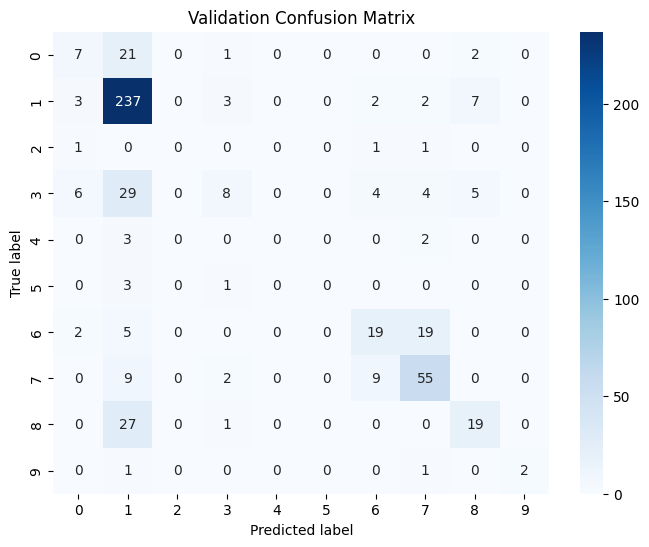

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.3684    0.2258    0.2800        31
           1     0.7075    0.9331    0.8048       254
           2     0.0000    0.0000    0.0000         3
           3     0.5000    0.1429    0.2222        56
           4     0.0000    0.0000    0.0000         5
           5     0.0000    0.0000    0.0000         4
           7     0.5429    0.4222    0.4750        45
           8     0.6548    0.7333    0.6918        75
           9     0.5758    0.4043    0.4750        47
          10     1.0000    0.5000    0.6667         4

    accuracy                         0.6622       524
   macro avg     0.4349    0.3362    0.3615       524
weighted avg     0.6178    0.6622    0.6179       524

Top-3 Accuracy: 0.9179


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.3348900544519687), np.float64(0.8436505449056938), np.float64(0.19232804232804235), np.float64(0.31463941023109016), np.float64(0.4164148733713951), np.float64(0.2931105058888563), np.float64(0.5), np.float64(0.6102986730465316), np.float64(0.7170856891666949), np.float64(0.5616546832177866), np.float64(0.5430347967310871)]
Validation PR-AUC (weighted): 0.6793
Validation PR-AUC (macro): 0.4843


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


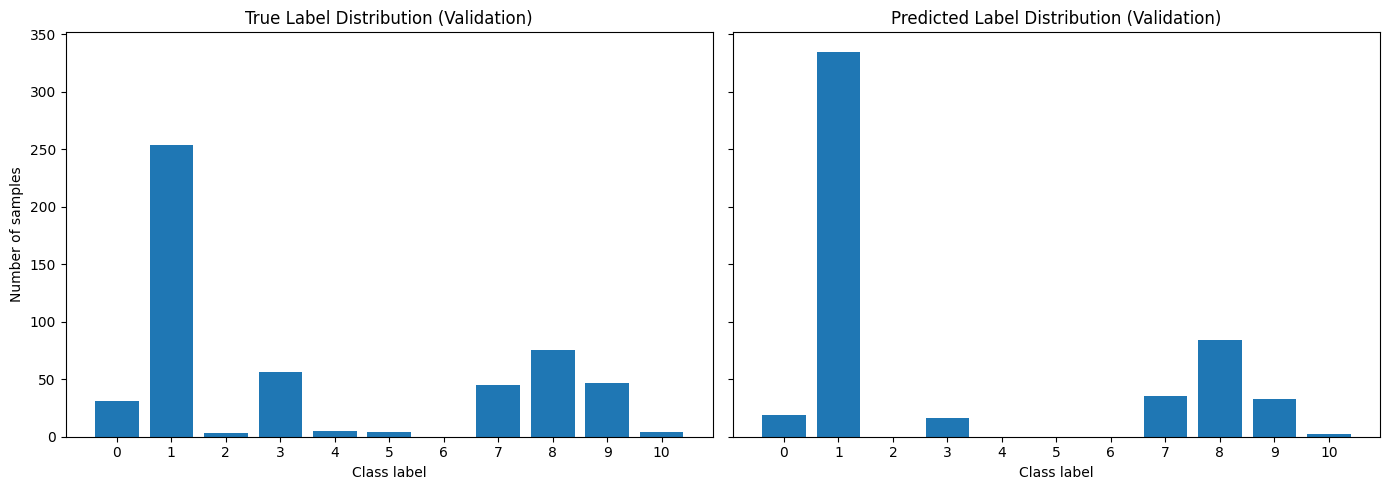

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

### (5) Learned feature fusion (Image + reduced metadata) with Concatenation

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = MultimodalModel_concat(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/ViT_4_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 24


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [ ]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6641221642494202


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.484375  0.077056       21
1  41-49  0.450712  0.051986       52
2  51-59  0.385480  0.053380      111
3  61-69  0.280260  0.046360      128
4  71-79  0.350985  0.049594      122
5    <30  0.500000  0.090909       10
6    >80  0.363394  0.051874       79

Age EO Gap
0.05730464954943112

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.342874  0.047118      208
1    male  0.307497  0.044687      316

Gender EO Gap
0.018904337208807503

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.349781  0.055024       50
2     3  0.350070  0.047111      319
3     4  0.314562  0.047225      107
4     5  0.221769  0.061846       37

Skin EO Gap
0.09761010011993634

Generalized Fairness Score
0.9420603043739417


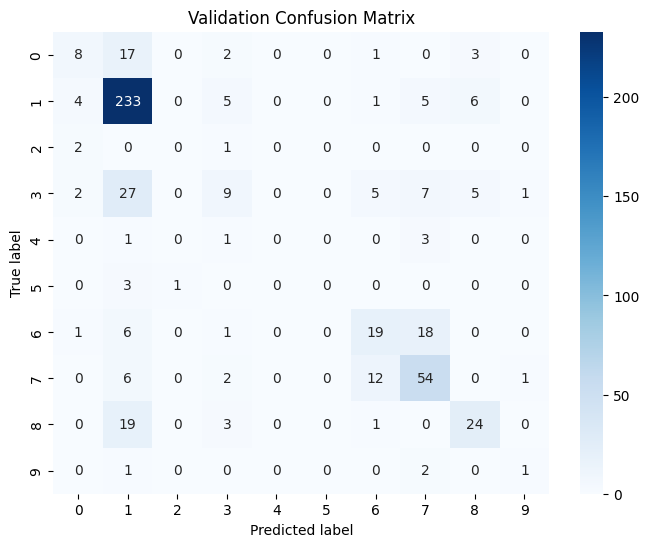

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.4706    0.2581    0.3333        31
           1     0.7444    0.9173    0.8219       254
           2     0.0000    0.0000    0.0000         3
           3     0.3750    0.1607    0.2250        56
           4     0.0000    0.0000    0.0000         5
           5     0.0000    0.0000    0.0000         4
           7     0.4872    0.4222    0.4524        45
           8     0.6067    0.7200    0.6585        75
           9     0.6316    0.5106    0.5647        47
          10     0.3333    0.2500    0.2857         4

    accuracy                         0.6641       524
   macro avg     0.3649    0.3239    0.3342       524
weighted avg     0.6166    0.6641    0.6281       524

Top-3 Accuracy: 0.9160


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.3977324001590177), np.float64(0.8696521738166854), np.float64(0.1806998556998557), np.float64(0.272536532042796), np.float64(0.5810202429149798), np.float64(0.3255799755799756), np.float64(0.5), np.float64(0.518649681875385), np.float64(0.7140329854595159), np.float64(0.5897303787129003), np.float64(0.3383923617875996)]
Validation PR-AUC (weighted): 0.6855
Validation PR-AUC (macro): 0.4807


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


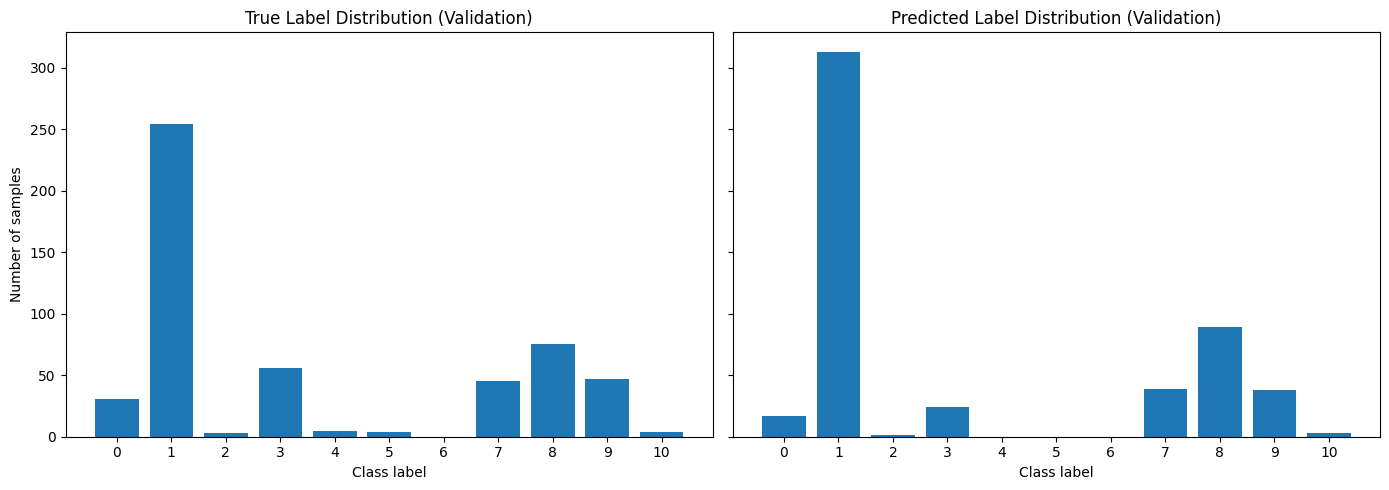

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

### (6) Cross Attention Image + reduced metadata
ViT with metadata (skin and age) and clinical close up

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

metadata_input_dim = next(iter(val_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_2_multimodal_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


metadata input dimension: 24
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 50.7MB/s]


#### Do more extensive analysis of the performance

In [ ]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_multimodal(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.6793892979621887


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.734375  0.058874       21
1  41-49  0.508384  0.050469       52
2  51-59  0.404439  0.047419      111
3  61-69  0.361948  0.045615      128
4  71-79  0.321662  0.050662      122
5    <30  1.000000  0.000000       10
6    >80  0.386075  0.047219       79

Age EO Gap
0.14724499430659024

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.416537  0.044583      208
1    male  0.416601  0.043405      316

Gender EO Gap
0.0006210561239444433

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.600000  0.050505       11
1     2  0.446272  0.048117       50
2     3  0.391546  0.045560      319
3     4  0.545507  0.043177      107
4     5  0.327211  0.067771       37

Skin EO Gap
0.07536727881273272

Generalized Fairness Score
0.9255888902522442


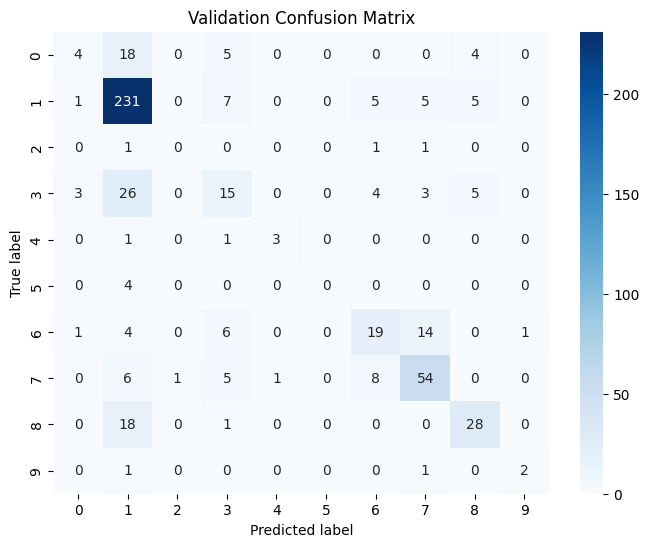

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.4444    0.1290    0.2000        31
           1     0.7452    0.9094    0.8191       254
           2     0.0000    0.0000    0.0000         3
           3     0.3750    0.2679    0.3125        56
           4     0.7500    0.6000    0.6667         5
           5     0.0000    0.0000    0.0000         4
           7     0.5135    0.4222    0.4634        45
           8     0.6923    0.7200    0.7059        75
           9     0.6667    0.5957    0.6292        47
          10     0.6667    0.5000    0.5714         4

    accuracy                         0.6794       524
   macro avg     0.4854    0.4144    0.4368       524
weighted avg     0.6428    0.6794    0.6503       524

Top-3 Accuracy: 0.9237


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.32351405704039865), np.float64(0.8517493399169953), np.float64(0.06780287613620946), np.float64(0.3339307006288592), np.float64(0.6265874891182688), np.float64(0.03914344299957452), np.float64(0.5), np.float64(0.5813795336122293), np.float64(0.7053415444628227), np.float64(0.6911478347505855), np.float64(0.5094819546378452)]
Validation PR-AUC (weighted): 0.6911
Validation PR-AUC (macro): 0.4755


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


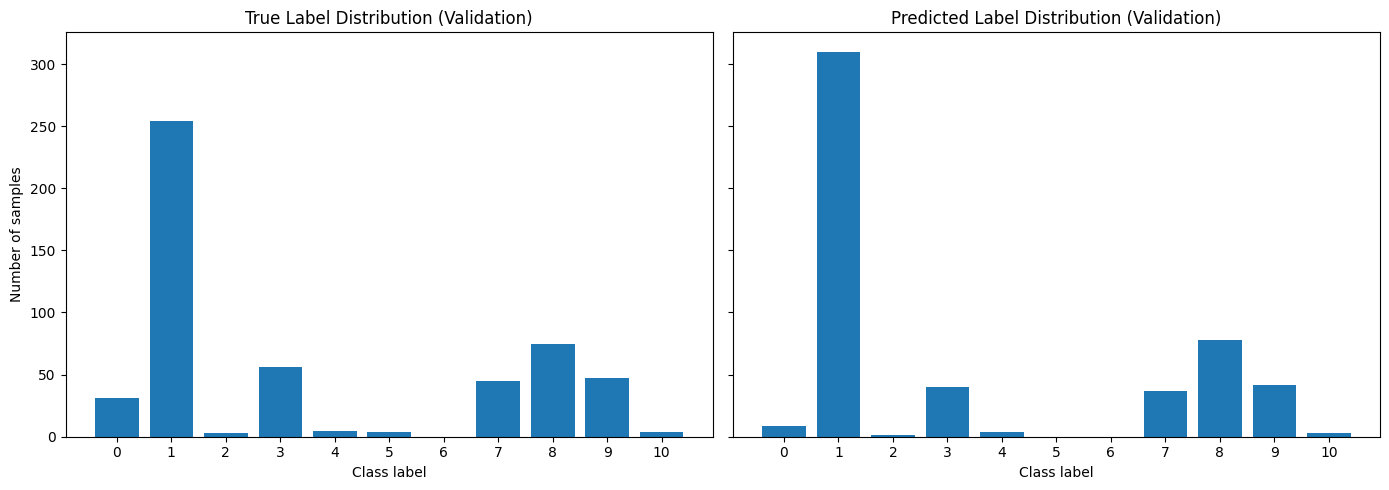

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## 2.3 Image + Image

## VALIDATION

## Load data:

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx     sex  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0    male   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0  female   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0    male   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0    male   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0    male   

   skin_tone_class             site  label_id  
0                1   head_neck_face         1  
1                5   head_neck_face         1  
2                3  lower_extremity         1  
3                3   head_neck_face         9  
4                3  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx     sex  skin_tone_class  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0    male                1   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0  female                5   
2  IL_0004688  ISIC_3624913  dermoscopic  

#### Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

_, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Clinical close-up images:

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)


# Dermoscopic images:

# Test
df_train_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Val: 524, Test: 525


#### Create the data transformers

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

test_transform = transforms.Compose([
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

#### Create the data loaders

In [ ]:
from utils import Milk10kDataset_images
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

test_dataset = Milk10kDataset_images(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    transform=test_transform
)

val_dataset = Milk10kDataset_images(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    transform=validation_transform
)

NUM_WORKERS = os.cpu_count()

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

train_loader, val_loader

Using device: cpu


(<torch.utils.data.dataloader.DataLoader at 0x7ba10be01a30>,
 <torch.utils.data.dataloader.DataLoader at 0x7ba10951fc20>)

## Test models:

## (7) MutualCrossAttention Image + Image
ViT for clinical and dermoscopic images

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Initialize wrapper
model = MutualCrossAttentionModel_images(num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_images_1_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [ ]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

@torch.no_grad()
def run_inference_images(model, loader, device):
    model.eval()
    all_logits = []
    all_targets = []

    for image_1, image_2, labels in loader:
        image_1 = image_1.to(device, non_blocking=True)
        image_2 = image_2.to(device, non_blocking=True)
        labels  = labels.to(device, non_blocking=True)

        outputs = model(image_1, image_2)  # forward pass

        all_logits.append(outputs.cpu())
        all_targets.append(labels.cpu())

    return (
        torch.cat(all_logits),   # [N, num_classes]
        torch.cat(all_targets)   # [N]
    )

logits, y_true = run_inference_images(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation accuracy: 0.7137404680252075


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

valid_age_mask = ~df_val_clinical["age_approx"].isna().values
y_true_age = y_true_n[valid_age_mask]
y_pred_age = y_pred_n[valid_age_mask]
age_groups = age_groups[valid_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.703125  0.068470       21
1  41-49  0.387586  0.051099       52
2  51-59  0.477733  0.039609      111
3  61-69  0.458644  0.030057      128
4  71-79  0.399150  0.041509      122
5    <30  0.833333  0.027273       10
6    >80  0.368218  0.045774       79

Age EO Gap
0.10842145291601216

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.405519  0.042964      208
1    male  0.444546  0.035033      316

Gender EO Gap
0.023479282111421772

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.466667  0.061869       11
1     2  0.383772  0.052355       50
2     3  0.444334  0.038376      319
3     4  0.598875  0.033449      107
4     5  0.274830  0.064353       37

Skin EO Gap
0.08162851317097276

Generalized Fairness Score
0.9288235839338644


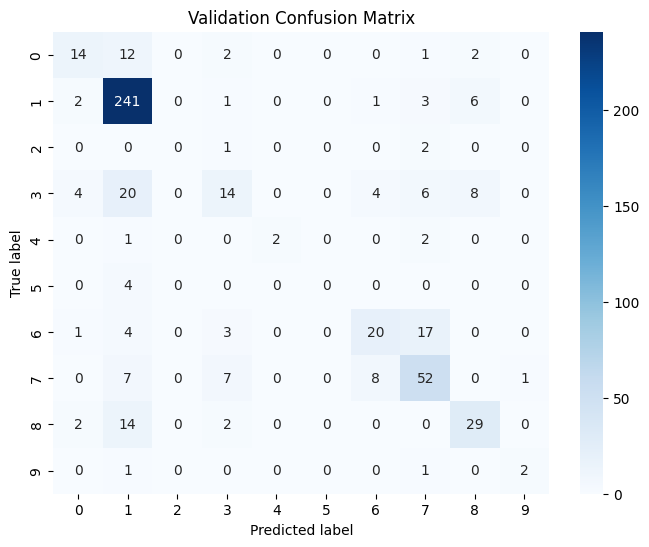

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.6087    0.4516    0.5185        31
           1     0.7928    0.9488    0.8638       254
           2     0.0000    0.0000    0.0000         3
           3     0.4667    0.2500    0.3256        56
           4     1.0000    0.4000    0.5714         5
           5     0.0000    0.0000    0.0000         4
           7     0.6061    0.4444    0.5128        45
           8     0.6190    0.6933    0.6541        75
           9     0.6444    0.6170    0.6304        47
          10     0.6667    0.5000    0.5714         4

    accuracy                         0.7137       524
   macro avg     0.5404    0.4305    0.4648       524
weighted avg     0.6832    0.7137    0.6882       524

Top-3 Accuracy: 0.9466


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.6052492097231389), np.float64(0.8763639419463944), np.float64(0.022243603810424086), np.float64(0.3925282327517524), np.float64(0.5733437881739474), np.float64(0.13635684605144419), np.float64(0.5), np.float64(0.6182695052670569), np.float64(0.7355407749210384), np.float64(0.6804761146059752), np.float64(0.5143686599470182)]
Validation PR-AUC (weighted): 0.7325
Validation PR-AUC (macro): 0.5141


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


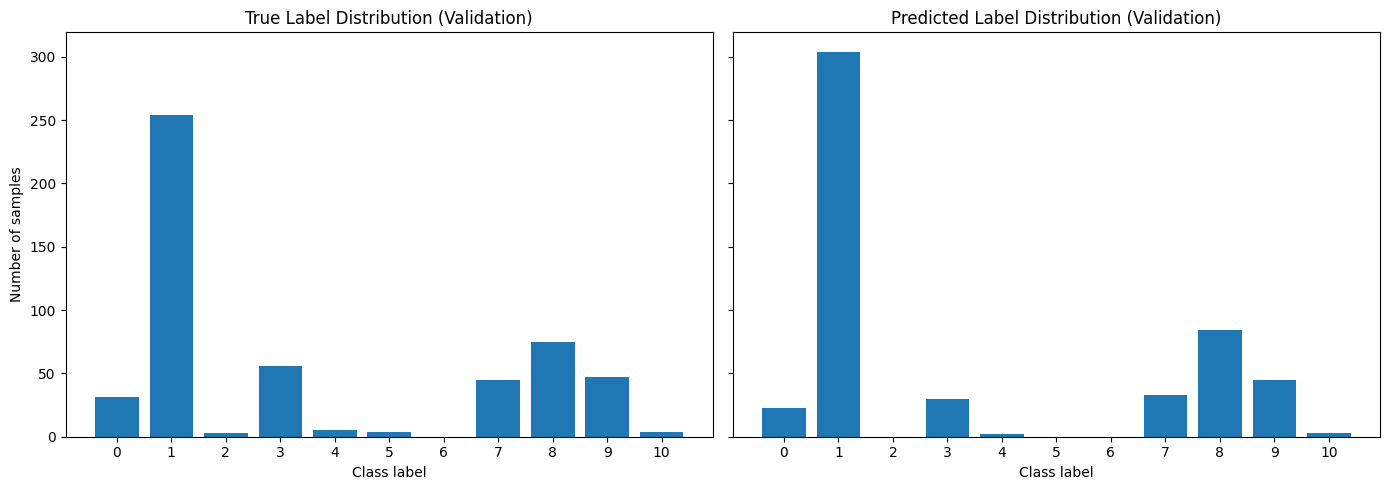

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## TEST

In [ ]:
import numpy as np

ages = df_test_clinical["age_approx"].values
print(df_test_clinical["age_approx"].value_counts())
ages = df_test_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-40", "41-50", "51-60", "61-70", "71-80", ">=81"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_test_clinical["sex"].values


skin_df = df_test_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
70.0    74
65.0    74
75.0    62
55.0    57
60.0    45
50.0    45
80.0    41
85.0    34
45.0    27
40.0    19
35.0    14
30.0    12
20.0     7
25.0     4
5.0      4
10.0     3
15.0     1
Name: count, dtype: int64
<30       19
31-39     26
41-49     46
51-59    102
61-69    119
71-79    136
>80       75
Name: count, dtype: int64
0      3
1     19
2     58
3    294
4    103
5     48
Name: count, dtype: int64
0-1     22
2       58
3      294
4      103
5       48
Name: count, dtype: int64


## Test models:

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Initialize wrapper
model = MutualCrossAttentionModel_images(num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_images_1_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [ ]:
# @title
from utils import run_inference_multimodal, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

@torch.no_grad()
def run_inference_images(model, loader, device):
    model.eval()
    all_logits = []
    all_targets = []

    for image_1, image_2, labels in loader:
        image_1 = image_1.to(device, non_blocking=True)
        image_2 = image_2.to(device, non_blocking=True)
        labels  = labels.to(device, non_blocking=True)

        outputs = model(image_1, image_2)  # forward pass

        all_logits.append(outputs.cpu())
        all_targets.append(labels.cpu())

    return (
        torch.cat(all_logits),   # [N, num_classes]
        torch.cat(all_targets)   # [N]
    )

logits, y_true = run_inference_images(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.645714282989502


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

test_age_mask = ~df_test_clinical["age_approx"].isna().values
y_true_age = y_true_n[test_age_mask]
y_pred_age = y_pred_n[test_age_mask]
age_groups = age_groups[test_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.275000  0.052121       26
1  41-49  0.366923  0.048806       46
2  51-59  0.324786  0.051694      102
3  61-69  0.463919  0.045258      119
4  71-79  0.337084  0.049029      136
5    <30  0.266667  0.034290       19
6    >80  0.297207  0.044946       75

Age EO Gap
0.042201926988385395

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.364329  0.040625      218
1    male  0.322719  0.049462      307

Gender EO Gap
0.025224191997490205

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.386364  0.071645       22
1     2  0.344420  0.050342       58
2     3  0.314036  0.042833      294
3     4  0.394444  0.041540      103
4     5  0.210000  0.062672       48

Skin EO Gap
0.0521265792815072

Generalized Fairness Score
0.9601491005775391


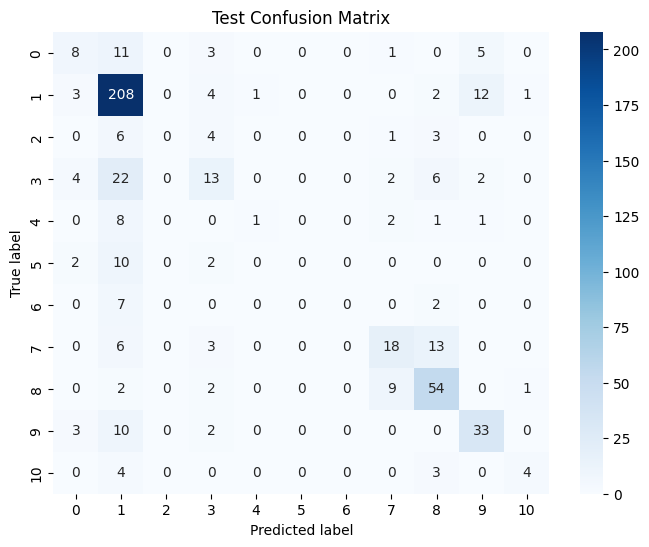

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.4000    0.2857    0.3333        28
           1     0.7075    0.9004    0.7924       231
           2     0.0000    0.0000    0.0000        14
           3     0.3939    0.2653    0.3171        49
           4     0.5000    0.0769    0.1333        13
           5     0.0000    0.0000    0.0000        14
           6     0.0000    0.0000    0.0000         9
           7     0.5455    0.4500    0.4932        40
           8     0.6429    0.7941    0.7105        68
           9     0.6226    0.6875    0.6535        48
          10     0.6667    0.3636    0.4706        11

    accuracy                         0.6457       525
   macro avg     0.4072    0.3476    0.3549       525
weighted avg     0.5775    0.6457    0.5985       525

Top-3 Accuracy: 0.8686


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Test PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Test PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 28 samples
Class 1 has 231 samples
Class 2 has 14 samples
Class 3 has 49 samples
Class 4 has 13 samples
Class 5 has 14 samples
Class 6 has 9 samples
Class 7 has 40 samples
Class 8 has 68 samples
Class 9 has 48 samples
Class 10 has 11 samples
PR-AUC per class: [np.float64(0.3159689098201819), np.float64(0.8963747946965757), np.float64(0.12813875125319144), np.float64(0.39220559014577705), np.float64(0.2845963392886804), np.float64(0.09330214565586127), np.float64(0.02206725496054948), np.float64(0.531602827472413), np.float64(0.8278125176243611), np.float64(0.7388558720211768), np.float64(0.6140262696240957)]
Test PR-AUC (weighted): 0.6893
Test PR-AUC (macro): 0.4405


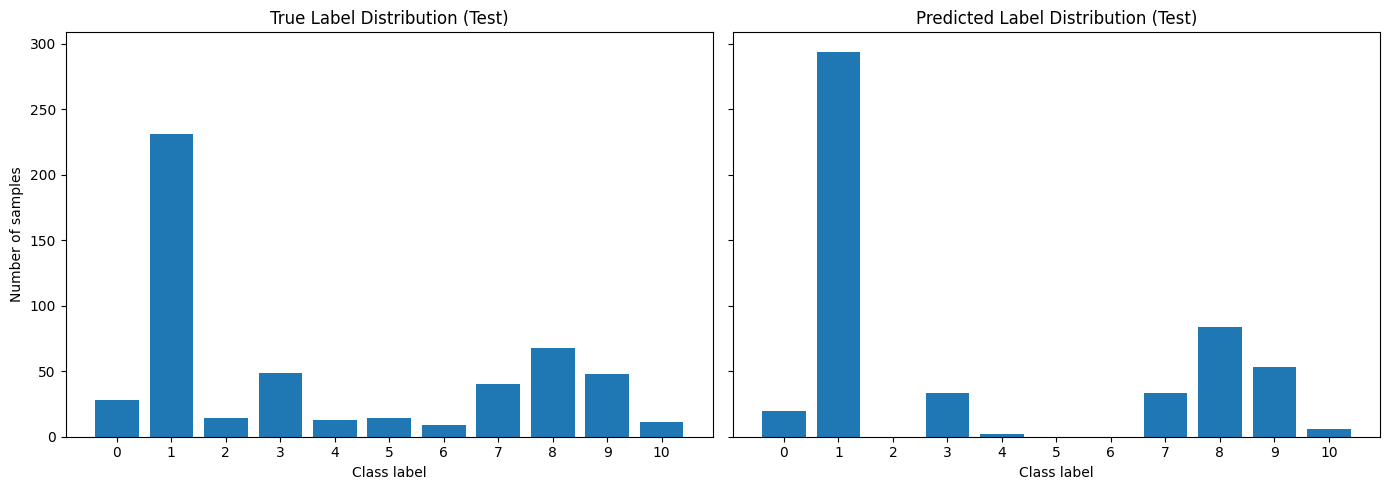

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Test)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Test)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## 2.3 Image + Image + full metadata

## VALIDATION

## Load data

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

#### Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

_, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Clinical close-up images:

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)


# Dermoscopic images:

# Train
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



#### Load the mapping between metadata values and their location in the one-hot-encoding vector

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

#### Create the data transformers

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

test_transform = transforms.Compose([
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

#### Create the datasets to be used in the dataloaders

In [ ]:
from utils import Milk10kDataset_images
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)

val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)


In [ ]:
NUM_WORKERS = os.cpu_count()

test_loader = DataLoader(
  test_dataset,
  batch_size=32,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=True
)

val_loader = DataLoader(
  val_dataset,
  batch_size=32,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=True
)

### Labels of the samples, regarding the sensitive groups

In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-40", "41-50", "51-60", "61-70", "71-80", ">=81"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

## Test models

## (8) MutualCrossAttention: Image + Image and fusion of full metadatata

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Initialize
model = MutualCrossAttentionModel_3modalities(metadata_dim=val_dataset.metadata_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_images_metadata_1_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

#### Do more extensive analysis of the performance

In [ ]:
# @title
from utils import run_inference_3_modalities, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_3_modalities(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

### Utility:

In [ ]:
# utility:
macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc_image_metadata(
    model, val_loader, device)


#### Equalized odds:

In [ ]:
fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
  )

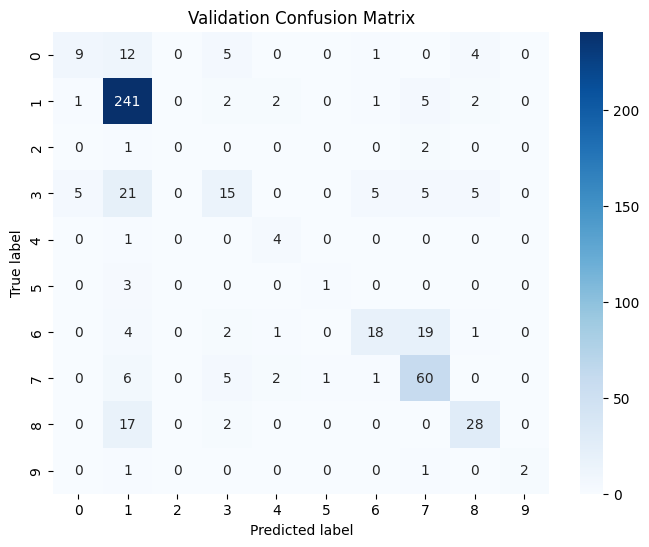

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.6000    0.2903    0.3913        31
           1     0.7850    0.9488    0.8592       254
           2     0.0000    0.0000    0.0000         3
           3     0.4839    0.2679    0.3448        56
           4     0.4444    0.8000    0.5714         5
           5     0.5000    0.2500    0.3333         4
           7     0.6923    0.4000    0.5070        45
           8     0.6522    0.8000    0.7186        75
           9     0.7000    0.5957    0.6437        47
          10     1.0000    0.5000    0.6667         4

    accuracy                         0.7214       524
   macro avg     0.5858    0.4853    0.5036       524
weighted avg     0.6990    0.7214    0.6937       524

Top-3 Accuracy: 0.9294


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Validation PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Validation PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 31 samples
Class 1 has 254 samples
Class 2 has 3 samples
Class 3 has 56 samples
Class 4 has 5 samples
Class 5 has 4 samples
Class 6 has 0 samples
Class 7 has 45 samples
Class 8 has 75 samples
Class 9 has 47 samples
Class 10 has 4 samples
PR-AUC per class: [np.float64(0.43672590881493883), np.float64(0.8890979385103882), np.float64(0.06348392986324021), np.float64(0.3442628435601499), np.float64(0.7145470029225617), np.float64(0.3004813762626262), np.float64(0.5), np.float64(0.6005298894418198), np.float64(0.761315556338574), np.float64(0.7013998293017291), np.float64(0.5265409706392677)]
Validation PR-AUC (weighted): 0.7305
Validation PR-AUC (macro): 0.5308


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


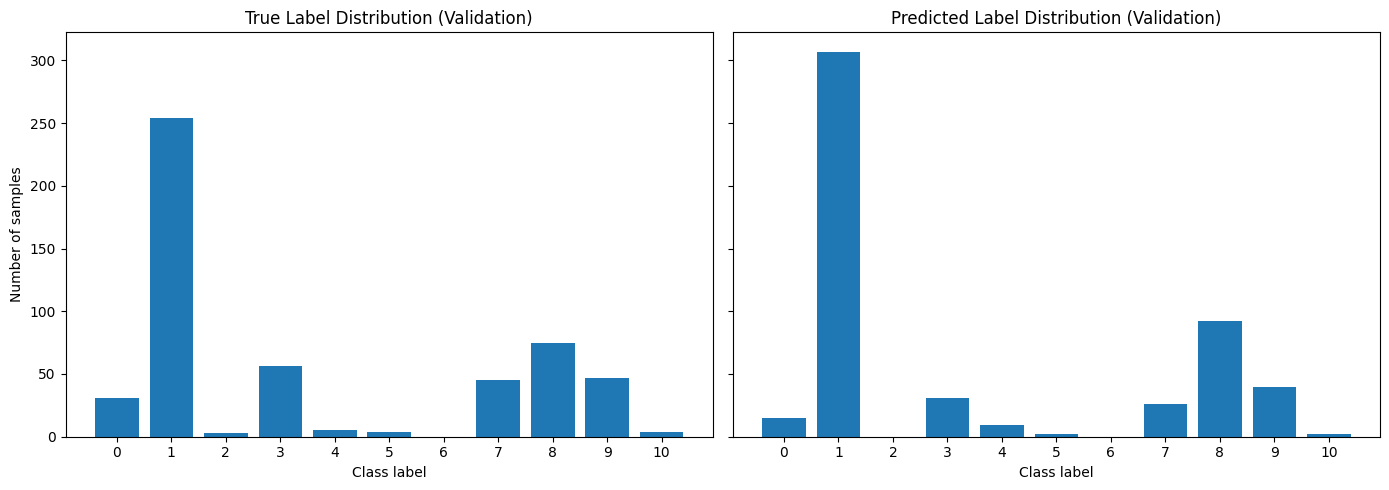

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Validation)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Validation)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

## TEST

In [ ]:
import numpy as np

ages = df_test_clinical["age_approx"].values
print(df_test_clinical["age_approx"].value_counts())
ages = df_test_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-40", "41-50", "51-60", "61-70", "71-80", ">=81"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_test_clinical["sex"].values


skin_df = df_test_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
70.0    74
65.0    74
75.0    62
55.0    57
60.0    45
50.0    45
80.0    41
85.0    34
45.0    27
40.0    19
35.0    14
30.0    12
20.0     7
25.0     4
5.0      4
10.0     3
15.0     1
Name: count, dtype: int64
<30       19
31-39     26
41-49     46
51-59    102
61-69    119
71-79    136
>80       75
Name: count, dtype: int64
0      3
1     19
2     58
3    294
4    103
5     48
Name: count, dtype: int64
0-1     22
2       58
3      294
4      103
5       48
Name: count, dtype: int64


### Test models:

In [ ]:
# @title
from VitClassifier_1_defnitions import *
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Initialize
model = MutualCrossAttentionModel_3modalities(metadata_dim=val_dataset.metadata_dim, num_classes=11).to(device)

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/Cross_images_metadata_1_best_stage2.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# now load the actual model weights
model.load_state_dict(checkpoint["model_state"])

Using device: cpu


<All keys matched successfully>

#### Do more extensive analysis of the performance

In [ ]:
# @title
from utils import run_inference_3_modalities, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


logits, y_true = run_inference_3_modalities(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.6361904740333557


#### Equalized odds:

In [ ]:
y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

age_groups = age_bins.astype(str)

test_age_mask = ~df_test_clinical["age_approx"].isna().values
y_true_age = y_true_n[test_age_mask]
y_pred_age = y_pred_n[test_age_mask]
age_groups = age_groups[test_age_mask]

age_results = equalized_odds_by_group_multiclass(y_true_age, y_pred_age, age_groups, 11)

print("\nAge Equalized Odds")
print(age_results)

age_gap = equalized_odds_gap(age_results)
print("\nAge EO Gap")
print(equalized_odds_gap(age_results))


gender_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, gender, 11)

print("\nGender Equalized Odds")
print(gender_results)

gender_gap = equalized_odds_gap(gender_results)
print("\nGender EO Gap")
print(equalized_odds_gap(gender_results))


skin_results = equalized_odds_by_group_multiclass(y_true_n, y_pred_n, skin, 11)

print("\nSkin Tone Equalized Odds")
print(skin_results)

skin_gap = equalized_odds_gap(skin_results)
print("\nSkin EO Gap")
print(equalized_odds_gap(skin_results))

overall_fairness = generalized_fairness_score(
    age_gap,
    gender_gap,
    skin_gap
)

print("\nGeneralized Fairness Score")
print(overall_fairness)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.257143  0.056147       26
1  41-49  0.420256  0.041673       46
2  51-59  0.321368  0.048087      102
3  61-69  0.430901  0.048596      119
4  71-79  0.352957  0.051353      136
5    <30  0.251282  0.039341       19
6    >80  0.300654  0.053769       75

Age EO Gap
0.047393553850786974

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.416577  0.037967      218
1    male  0.312225  0.054392      307

Gender EO Gap
0.06038840908438828

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.568182  0.059163       22
1     2  0.243642  0.061036       58
2     3  0.257833  0.049116      294
3     4  0.422500  0.038047      103
4     5  0.388333  0.047559       48

Skin EO Gap
0.08713292956874488

Generalized Fairness Score
0.9350283691653599


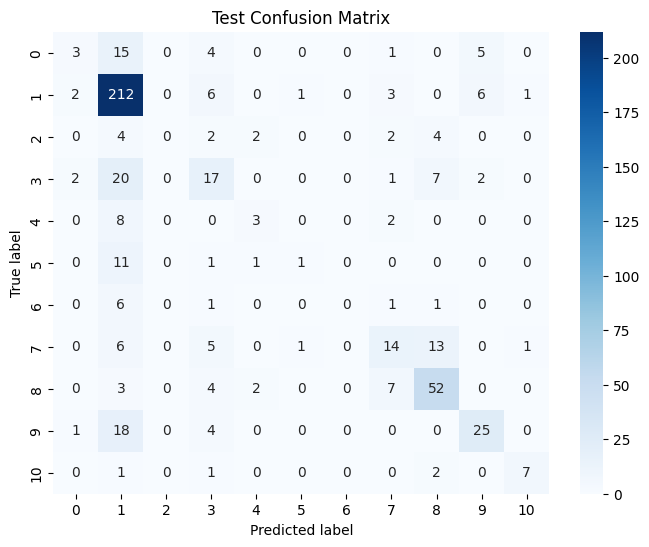

In [ ]:
# @title
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test Confusion Matrix")
plt.show()


In [ ]:
# @title
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

top3_acc = top_k_from_logits(logits, y_true, k=3)
print(f"Top-3 Accuracy: {top3_acc:.4f}")

              precision    recall  f1-score   support

           0     0.3750    0.1071    0.1667        28
           1     0.6974    0.9177    0.7925       231
           2     0.0000    0.0000    0.0000        14
           3     0.3778    0.3469    0.3617        49
           4     0.3750    0.2308    0.2857        13
           5     0.3333    0.0714    0.1176        14
           6     0.0000    0.0000    0.0000         9
           7     0.4516    0.3500    0.3944        40
           8     0.6582    0.7647    0.7075        68
           9     0.6579    0.5208    0.5814        48
          10     0.7778    0.6364    0.7000        11

    accuracy                         0.6362       525
   macro avg     0.4276    0.3587    0.3734       525
weighted avg     0.5764    0.6362    0.5911       525

Top-3 Accuracy: 0.8800


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np

num_classes = logits.shape[1]

# Convert logits -> probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# One-hot encode labels
y_true_oh = label_binarize(
    y_true.cpu().numpy(),
    classes=list(range(num_classes))
)

# Class counts (for weighting)
counts = np.sum(y_true_oh, axis=0)

for i, c in enumerate(counts):
    print(f"Class {i} has {c} samples")

# Compute PR-AUC per class
pr_aucs = []

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_oh[:, i],
        probs[:, i]
    )

    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)

# Weighted average (same logic as your ROC code)
weights = counts / counts.sum()
weighted_pr_auc = np.sum(np.array(pr_aucs) * weights)

print("PR-AUC per class:", pr_aucs)
print(f"Test PR-AUC (weighted): {weighted_pr_auc:.4f}")
macro_pr_auc = np.mean(pr_aucs)
print(f"Test PR-AUC (macro): {macro_pr_auc:.4f}")

Class 0 has 28 samples
Class 1 has 231 samples
Class 2 has 14 samples
Class 3 has 49 samples
Class 4 has 13 samples
Class 5 has 14 samples
Class 6 has 9 samples
Class 7 has 40 samples
Class 8 has 68 samples
Class 9 has 48 samples
Class 10 has 11 samples
PR-AUC per class: [np.float64(0.2386618873849181), np.float64(0.8838600386670795), np.float64(0.16296273152240887), np.float64(0.35011004985420785), np.float64(0.3176475173107395), np.float64(0.22320436695297105), np.float64(0.03168834149178112), np.float64(0.4690761812548692), np.float64(0.8098506938144654), np.float64(0.7057068761653214), np.float64(0.7182946831738729)]
Test PR-AUC (weighted): 0.6732
Test PR-AUC (macro): 0.4465


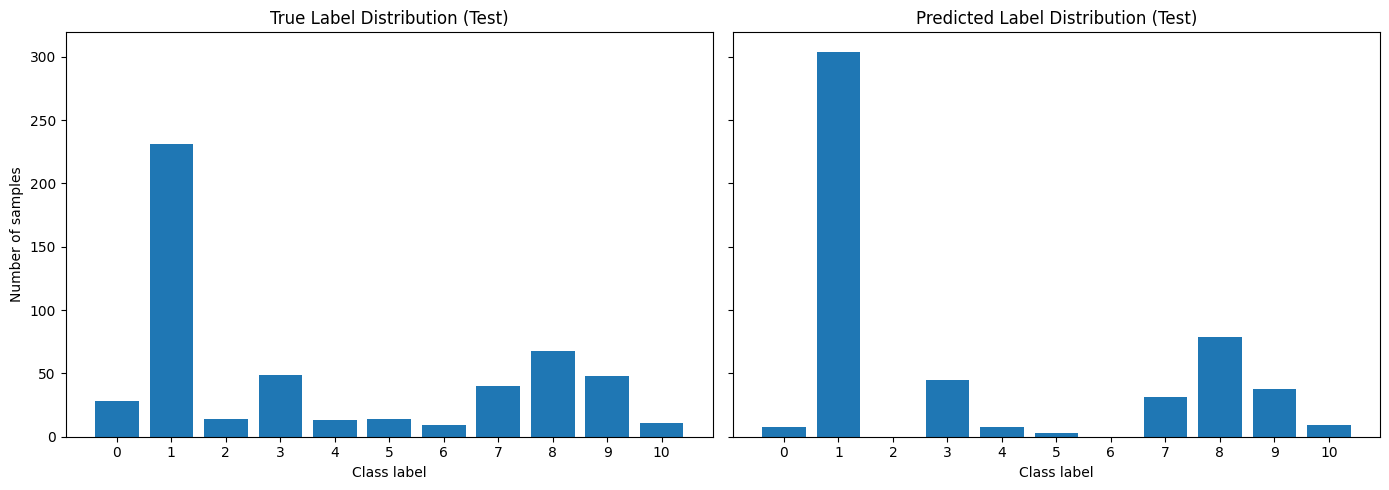

In [ ]:
# @title
num_classes = 11
classes = np.arange(num_classes)

true_counts = np.bincount(y_true, minlength=num_classes)
pred_counts = np.bincount(y_pred, minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].bar(classes, true_counts)
axes[0].set_title("True Label Distribution (Test)")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(classes)

# Predicted labels
axes[1].bar(classes, pred_counts)
axes[1].set_title("Predicted Label Distribution (Test)")
axes[1].set_xlabel("Class label")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()